# S3 Data Processing and Analysis
> by Lei Ding, updated Apr. 2026

In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False 

## 1. Pandas基础

### 1.1 Series, DataFrame与索引

In [2]:
# 1. 认识Series
s1 = pd.Series([4, 7, -5, 3])
s2 = pd.Series(np.array([4, 7, -5, 3]))
s3 = pd.Series(['a', 'b', 'cd', 'efgh'])
s4 = pd.Series(s1.values, index=['a', 'bc', 'd', 'e'])
s5 = pd.Series({2001: 17.8, 2002: 20.1, 2003: 16.5})

s = pd.Series([4, 7, -5, 3], index=['one', 'two', 'three', 'four'], name='Numbers')
s

one      4
two      7
three   -5
four     3
Name: Numbers, dtype: int64

In [3]:
# 2. Series的主要属性
print(s.values, type(s.values))  # 数据
print(s.index, type(s.index))  # 索引
print(s.name, s.index.name)

s.ndim, s.shape, s.size, s.dtype

[ 4  7 -5  3] <class 'numpy.ndarray'>
Index(['one', 'two', 'three', 'four'], dtype='str') <class 'pandas.Index'>
Numbers None


(1, (4,), 4, dtype('int64'))

In [4]:
# 4. 认识DataFrame
df1 = pd.DataFrame([['a', 'b', 'c'], ['d', 'e', 'f']])  # 等长度列表

df2 = pd.DataFrame(np.array([[96, 97, 98], [99, 100, 11]]))  # 二维数组

df3 = pd.DataFrame({'state': ['Ohio', ' Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
                       'year': [2000, 2001, 2002, 2001, 2002, 2003],
                       'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]})

df4 = pd.DataFrame([{'No1': 'Ohio', 'No2': 'Ohio', 'No3': 'Ohio',
                        'No4': 'Nevada', 'No5': 'Nevada', 'No6': 'Nevada'},
                       {'No1': 2000, 'No2': 2001, 'No3': 2002, 'No4': 2001, 'No5': 2002, 'No6': 2003},
                       {'No1': 1.5, 'No2': 1.7, 'No3': 3.6, 'No4': 2.4, 'No5': 2.9, 'No6': 3.2}])

df5 = pd.DataFrame({'state': {'No1': 'Ohio', 'No2': 'Ohio', 'No3': 'Ohio',
                                 'No4': 'Nevada', 'No5': 'Nevada', 'No6': 'Nevada'},
                       'year': {'No1': 2000, 'No2': 2001, 'No3': 2002, 'No4': 2001, 'No5': 2002, 'No6': 2003},
                       'pop': {'No1': 1.5, 'No2': 1.7, 'No3': 3.6, 'No4': 2.4, 'No5': 2.9, 'No6': 3.2}})

df6 = pd.DataFrame({'state': pd.Series(['Ohio', ' Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
                                          index=['No1', 'No2', 'No3', 'No4', 'No5', 'No6']),
                       'year': pd.Series([2000, 2001, 2002, 2001, 2002, 2003],
                                         index=['No1', 'No2', 'No3', 'No4', 'No5', 'No6']),
                       'pop': pd.Series([1.5, 1.7, 3.6, 2.4, 2.9, 3.2],
                                        index=['No1', 'No2', 'No3', 'No4', 'No5', 'No6'])})

df7 = pd.DataFrame(df1.values, index=['one', 'two'], columns=['No1', 'No2', 'No3'])

df = pd.DataFrame(np.array([['Ohio', 2000, 1.5], ['Ohio', 2001, 1.7], ['Ohio', 2002, 3.6],
                            ['Nevada', 2001, 2.4], ['Nevada', 2002, 2.9], ['Nevada', 2003, 3.2]]),
                  index=['No1', 'No2', 'No3', 'No4', 'No5', 'No6'],
                  columns=['state', 'year', 'pop'])
df

,state,year,pop
No1,Ohio,2000,1.5
No2,Ohio,2001,1.7
No3,Ohio,2002,3.6
No4,Nevada,2001,2.4
No5,Nevada,2002,2.9
No6,Nevada,2003,3.2


In [5]:
# 5. DataFrame的主要属性
print(df.values, type(df.values))
print(df.index, type(df.index))  # 行索引
print(df.columns, type(df.columns))  # 列索引
print(df.axes, type(df.axes))
# 没有name

df.ndim, df.shape, df.size, df.dtypes # 没有dtype

[['Ohio' '2000' '1.5']
 ['Ohio' '2001' '1.7']
 ['Ohio' '2002' '3.6']
 ['Nevada' '2001' '2.4']
 ['Nevada' '2002' '2.9']
 ['Nevada' '2003' '3.2']] <class 'numpy.ndarray'>
Index(['No1', 'No2', 'No3', 'No4', 'No5', 'No6'], dtype='str') <class 'pandas.Index'>
Index(['state', 'year', 'pop'], dtype='str') <class 'pandas.Index'>
[Index(['No1', 'No2', 'No3', 'No4', 'No5', 'No6'], dtype='str'), Index(['state', 'year', 'pop'], dtype='str')] <class 'list'>


(2,
 (6, 3),
 18,
 state    str
 year     str
 pop      str
 dtype: object)

In [6]:
# 6. Series的索引操作
s = pd.Series([7, -5, 3, 11, 2], index=['a', 'b', 'c', 'd', 'e'])

# print(s[1], '\n') # 按位置索引，已废弃

# 按标签
print(s['b'], '\n')
print(s['b':'d'], '\n')  # 包含开始和结束
print(s[['d', 'e', 'a']], '\n')

# 布尔索引
print(s[s > 0], '\n')

# loc与iloc运算符（推荐）
print(s.loc['a': 'b'])
print(s.iloc[:2])

-5 

b    -5
c     3
d    11
dtype: int64 

d    11
e     2
a     7
dtype: int64 

a     7
c     3
d    11
e     2
dtype: int64 

a    7
b   -5
dtype: int64
a    7
b   -5
dtype: int64


In [7]:
# 使用索引
print('d' in s)
s ** 2  # 不改变索引

t = s.loc['a']

True


In [9]:
# 7. DataFrame的索引操作
df = pd.DataFrame(np.arange(12).reshape(3, 4),
                  index=['a', 'b', 'c'], columns=['A', 'B', 'C', 'D'])
print(df, '\n')

# 列索引，返回Series
print(df['A'], '\n')
print(df.B, '\n')

# 列的神奇索引，返回DataFrame
print(df[['A']], '\n')
print(df[['D', 'C', 'A']])

   A  B   C   D
a  0  1   2   3
b  4  5   6   7
c  8  9  10  11 

a    0
b    4
c    8
Name: A, dtype: int64 

a    1
b    5
c    9
Name: B, dtype: int64 

   A
a  0
b  4
c  8 

    D   C  A
a   3   2  0
b   7   6  4
c  11  10  8


In [10]:
# 行切片，返回DataFrame
print(df[1:], '\n')  # 将废弃
print(df['b':'c'], '\n')

# df[1], df['a'] 错误！

# 结果再索引
print(df['C']['b'], '\n')  # Series
print(df['C']['a':'b'], '\n')

print(df[['D', 'C']][:2], '\n')  # DataFrame
print(df[:2][['D', 'C']], '\n')

   A  B   C   D
b  4  5   6   7
c  8  9  10  11 

   A  B   C   D
b  4  5   6   7
c  8  9  10  11 

6 

a    2
b    6
Name: C, dtype: int64 

   D  C
a  3  2
b  7  6 

   D  C
a  3  2
b  7  6 



In [11]:
# 8. DataFrame的索引操作2
df= pd.DataFrame(np.arange(12).reshape(3, 4),
                 index=['a', 'b', 'c'], columns=['A', 'B', 'C', 'D'])
print(df.loc['a', 'D'], '\n')
print(df.loc['a'], '\n')
print(df.loc['a', :], '\n')
print(df.loc[:, 'A'])

3 

A    0
B    1
C    2
D    3
Name: a, dtype: int64 

A    0
B    1
C    2
D    3
Name: a, dtype: int64 

a    0
b    4
c    8
Name: A, dtype: int64


In [12]:
print(df.loc['a':'b'], '\n')
print(df.loc[:, 'A':'B'], '\n')
print(df.loc[['a', 'b'], ['A', 'D']])

   A  B  C  D
a  0  1  2  3
b  4  5  6  7 

   A  B
a  0  1
b  4  5
c  8  9 

   A  D
a  0  3
b  4  7


In [13]:
print(df.iloc[0, 3], '\n')
print(df.iloc[0], '\n')
print(df.iloc[:, 0])

3 

A    0
B    1
C    2
D    3
Name: a, dtype: int64 

a    0
b    4
c    8
Name: A, dtype: int64


In [14]:
print(df.iloc[:2], '\n')
print(df.iloc[:, :2], '\n')
print(df.iloc[[0, 1], [1, 0]])

   A  B  C  D
a  0  1  2  3
b  4  5  6  7 

   A  B
a  0  1
b  4  5
c  8  9 

   B  A
a  1  0
b  5  4


In [15]:
# 9. Series重建索引
s = pd.Series([7, -5, 3, 11], index=['bill', 'hope', 'mike', 'yana'])
print(s.reindex(['mike', 'yana', 'lynn', 'vicky', 'hope']), '\n')

print(pd.Series(s, index=['lynn', 'bill', 'mike']))  # 自动对齐索引

mike      3.0
yana     11.0
lynn      NaN
vicky     NaN
hope     -5.0
dtype: float64 

lynn    NaN
bill    7.0
mike    3.0
dtype: float64


In [16]:
print(s.reindex(['bill', 'yana', 'lynn', 'vicky'], fill_value=999), '\n')
print(s.reindex(['d', 'e', 'a', 'z', 'j', 's'], method='ffill'), '\n')  # 要求原索引递增或递减排序，且索引间可比较
print(s.reindex(['d', 'e', 'a', 'z', 'j', 's'], method='bfill'))

bill       7
yana      11
lynn     999
vicky    999
dtype: int64 

d     7.0
e     7.0
a     NaN
z    11.0
j    -5.0
s     3.0
dtype: float64 

d    -5.0
e    -5.0
a     7.0
z     NaN
j     3.0
s    11.0
dtype: float64


In [17]:
#  7. DataFrame重建索引
frame = pd.DataFrame(np.arange(9).reshape(3, 3),
                     index=['a', 'c', 'd'], columns=['Xian', 'Shanghai', 'Beijing'])
print(frame.reindex(['a', 'b', 'c', 'd']), '\n')
print(frame.reindex(columns=['Shanghai', 'Jinan', 'Beijing']), '\n')
print(frame.reindex(['Shanghai', 'Jinan', 'Beijing'], axis='columns'), '\n')

pd.DataFrame(frame, columns=['Shanghai', 'Jinan', 'Beijing'])  # 自动对齐索引

   Xian  Shanghai  Beijing
a   0.0       1.0      2.0
b   NaN       NaN      NaN
c   3.0       4.0      5.0
d   6.0       7.0      8.0 

   Shanghai  Jinan  Beijing
a         1    NaN        2
c         4    NaN        5
d         7    NaN        8 

   Shanghai  Jinan  Beijing
a         1    NaN        2
c         4    NaN        5
d         7    NaN        8 



,Shanghai,Jinan,Beijing
a,1,NaN,2
c,4,NaN,5
d,7,NaN,8


In [19]:
# 重命名轴索引
data = pd.DataFrame(np.arange(12).reshape(3, 4),
                    index=['BEIJING', 'SHANGHAI', 'GUANGZHOU'],
                    columns=['one', 'two', 'three', 'four'])
print(data, '\n')
print(data.rename(index={'BEIJING': 'A'}, columns={'four': 'last'}))

           one  two  three  four
BEIJING      0    1      2     3
SHANGHAI     4    5      6     7
GUANGZHOU    8    9     10    11 

           one  two  three  last
A            0    1      2     3
SHANGHAI     4    5      6     7
GUANGZHOU    8    9     10    11


In [20]:
print(data.rename(index=str.title, columns=str.upper), '\n')  # 使用字符串函数改变索引
data.rename(str.lower, axis='columns')

           ONE  TWO  THREE  FOUR
Beijing      0    1      2     3
Shanghai     4    5      6     7
Guangzhou    8    9     10    11 



,one,two,three,four
BEIJING,0,1,2,3
SHANGHAI,4,5,6,7
GUANGZHOU,8,9,10,11


In [21]:
data.index = list('abc')  # 替换整个索引，直接修改原DataFrame
data

,one,two,three,four
a,0,1,2,3
b,4,5,6,7
c,8,9,10,11


### 1.2 Pandas基本功能

In [22]:
# 8. Series修改数据
obj = pd.Series(np.arange(5.), index=['a', 'b', 'c', 'd', 'e'])
obj[:3] = 999
obj['x'] = 888
del obj['b']
print(obj, '\n')

print(obj.drop('c'), '\n')
print(obj.drop(['c', 'a']), '\n')
obj.drop(['x'], inplace=True)
obj

a    999.0
c    999.0
d      3.0
e      4.0
x    888.0
dtype: float64 

a    999.0
d      3.0
e      4.0
x    888.0
dtype: float64 

d      3.0
e      4.0
x    888.0
dtype: float64 



a    999.0
c    999.0
d      3.0
e      4.0
dtype: float64

In [23]:
# 9. DataFrame修改数据
frame = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=['a', 'b', 'c', 'd'], columns=['A', 'B', 'C', 'D'])
frame['A'] = 999
frame['X'] = [777, 888, 999, 0]
frame.loc['x'] = 111
del frame['B']  # 使用标签
print(frame, '\n')

     A    C    D    X
a  999    2    3  777
b  999    6    7  888
c  999   10   11  999
d  999   14   15    0
x  111  111  111  111 



In [24]:
print(frame.drop('a'), '\n')
print(frame.drop(['a', 'd']), '\n')
print(frame.drop(columns='A'), '\n')
print(frame.drop(['A', 'D'], axis=1))

     A    C    D    X
b  999    6    7  888
c  999   10   11  999
d  999   14   15    0
x  111  111  111  111 

     A    C    D    X
b  999    6    7  888
c  999   10   11  999
x  111  111  111  111 

     C    D    X
a    2    3  777
b    6    7  888
c   10   11  999
d   14   15    0
x  111  111  111 

     C    X
a    2  777
b    6  888
c   10  999
d   14    0
x  111  111


In [26]:
# 10. 算术运算与数据对齐
s1 = pd.Series([7.3, -2.5, 3.4, 1.5], index=['a', 'c', 'd', 'e'])
s2 = pd.Series([-2.1, 3.6, -1.5, 4, 3.1], index=['a', 'c', 'e', 'f', 'g'])
print(s1 + s2, '\n')
print(s1.add(s2, fill_value=100))

a    5.2
c    1.1
d    NaN
e    0.0
f    NaN
g    NaN
dtype: float64 

a      5.2
c      1.1
d    103.4
e      0.0
f    104.0
g    103.1
dtype: float64


In [27]:
df1 = pd.DataFrame(np.arange(9.).reshape(3, 3), columns=list('BCD'), index=list('abc'))
df2 = pd.DataFrame(np.arange(12.).reshape(4, 3), columns=list('BDE'), index=list('dabe'))
print(df1 + df2, '\n')
print(df1.add(df2, fill_value=100), '\n')

df1.rdiv(1)

     B   C     D   E
a  3.0 NaN   6.0 NaN
b  9.0 NaN  12.0 NaN
c  NaN NaN   NaN NaN
d  NaN NaN   NaN NaN
e  NaN NaN   NaN NaN 

       B      C      D      E
a    3.0  101.0    6.0  105.0
b    9.0  104.0   12.0  108.0
c  106.0  107.0  108.0    NaN
d  100.0    NaN  101.0  102.0
e  109.0    NaN  110.0  111.0 



,B,C,D
a,inf,1.000000,0.500
b,0.333333,0.250000,0.200
c,0.166667,0.142857,0.125


In [28]:
# 11. DataFrame与Series间的运算
df = pd.DataFrame(np.arange(12.).reshape((4, 3)),
                 columns=list('ABC'), index=list('abcd'))
print(df, '\n')
print(df - df.iloc[0])

     A     B     C
a  0.0   1.0   2.0
b  3.0   4.0   5.0
c  6.0   7.0   8.0
d  9.0  10.0  11.0 

     A    B    C
a  0.0  0.0  0.0
b  3.0  3.0  3.0
c  6.0  6.0  6.0
d  9.0  9.0  9.0


In [29]:
sr = pd.Series(range(3), index=list('ACD'))
print(sr, '\n')
print(df + sr, '\n\n')

sr1 = df['B']
print(sr1, '\n')
print(df.sub(sr1, axis='index'))

A    0
C    1
D    2
dtype: int64 

     A   B     C   D
a  0.0 NaN   3.0 NaN
b  3.0 NaN   6.0 NaN
c  6.0 NaN   9.0 NaN
d  9.0 NaN  12.0 NaN 


a     1.0
b     4.0
c     7.0
d    10.0
Name: B, dtype: float64 

     A    B    C
a -1.0  0.0  1.0
b -1.0  0.0  1.0
c -1.0  0.0  1.0
d -1.0  0.0  1.0


In [30]:
# 12. 函数应用与映射
df = pd.DataFrame(np.random.randn(4, 3),
                      columns=list('ABC'), index=list('abcd'))
print(df, '\n')
print(np.abs(df), '\n')  # numpy中的ufunc

print(df.sum(), '\n')  # 统计方法
print(df.sum(axis='columns'), '\n')

          A         B         C
a  1.201326  1.746113 -4.280949
b  0.740893 -1.004124 -2.175335
c -1.039197  1.517310  0.278477
d  0.627965 -0.022716 -1.182067 

          A         B         C
a  1.201326  1.746113  4.280949
b  0.740893  1.004124  2.175335
c  1.039197  1.517310  0.278477
d  0.627965  0.022716  1.182067 

A    1.530987
B    2.236583
C   -7.359874
dtype: float64 

a   -1.333509
b   -2.438567
c    0.756591
d   -0.576819
dtype: float64 



In [31]:
print(df.apply(lambda x: x.max() - x.min()), '\n')
print(df.apply(lambda x: x.max() - x.min(), axis='columns'), '\n')

print(df['B'].map(abs))

A    2.240523
B    2.750237
C    4.559425
dtype: float64 

a    6.027062
b    2.916228
c    2.556507
d    1.810032
dtype: float64 

a    1.746113
b    1.004124
c    1.517310
d    0.022716
Name: B, dtype: float64


In [32]:
# 13. 数据排序: 按索引
obj = pd.Series(range(4), index=list('dabc'))
print(obj, '\n')
print(obj.sort_index(), '\n')
print(obj.sort_index(ascending=False), '\n')

d    0
a    1
b    2
c    3
dtype: int64 

a    1
b    2
c    3
d    0
dtype: int64 

d    0
c    3
b    2
a    1
dtype: int64 



In [33]:
frame = pd.DataFrame(np.arange(8).reshape(2, 4), 
                     index=list('ca'), columns=list('DABC'))
print(frame, '\n')
print(frame.sort_index(axis='columns'), '\n')
print(frame.sort_index(axis=1, ascending=False), '\n')

   D  A  B  C
c  0  1  2  3
a  4  5  6  7 

   A  B  C  D
c  1  2  3  0
a  5  6  7  4 

   D  C  B  A
c  0  3  2  1
a  4  7  6  5 



In [34]:
# 14. 数据排序：按值
obj = pd.Series([4, np.nan, 7, np.nan, -3, 2])
print(obj.sort_values(), '\n')

4   -3.0
5    2.0
0    4.0
2    7.0
1    NaN
3    NaN
dtype: float64 



In [35]:
frame = pd.DataFrame({'b': [4, 7, -3, 2], 'a': [0, 1, 0, 1]})
print(frame, '\n')
print(frame.sort_values(by='b'), '\n')
print(frame.sort_values(by=0, axis=1), '\n')
print(frame.sort_values(['a', 'b']))

   b  a
0  4  0
1  7  1
2 -3  0
3  2  1 

   b  a
2 -3  0
3  2  1
0  4  0
1  7  1 

   a  b
0  0  4
1  1  7
2  0 -3
3  1  2 

   b  a
2 -3  0
0  4  0
3  2  1
1  7  1


### 1.3 统计描述

In [36]:
# 15. 统计描述
df = pd.DataFrame(np.arange(12).reshape(3, 4),
                 columns=list('ABCD'))
print(df, '\n')
print(df.sum(), '\n')
print(df.max(), '\n')
print(df.min(axis=1), '\n')

df.describe()
#df['A'].describe()

   A  B   C   D
0  0  1   2   3
1  4  5   6   7
2  8  9  10  11 

A    12
B    15
C    18
D    21
dtype: int64 

A     8
B     9
C    10
D    11
dtype: int64 

0    0
1    4
2    8
dtype: int64 



,A,B,C,D
count,3.0,3.0,3.0,3.0
mean,4.0,5.0,6.0,7.0
std,4.0,4.0,4.0,4.0
min,0.0,1.0,2.0,3.0
25%,2.0,3.0,4.0,5.0
50%,4.0,5.0,6.0,7.0
75%,6.0,7.0,8.0,9.0
max,8.0,9.0,10.0,11.0


In [37]:
# 相关性分析
#pd.read_csv('yahoo_price.csv', index_col=0).to_pickle('yahoo_price.pkl')
#pd.read_csv('yahoo_volume.csv', index_col=0).to_pickle('yahoo_volume.pkl')
price = pd.read_pickle("yahoo_price.pkl")  # 股价
volume = pd.read_pickle("yahoo_volume.pkl")  # 交易量
returns = price.pct_change()  # 计算当前值相对于前一个值的百分比变化
returns.tail()

,AAPL,GOOG,IBM,MSFT
Date,,,,
2016-10-17,-0.000680,0.001837,0.002072,-0.003483
2016-10-18,-0.000681,0.019616,-0.026168,0.007690
2016-10-19,-0.002979,0.007846,0.003583,-0.002255
2016-10-20,-0.000512,-0.005652,0.001719,-0.004867
2016-10-21,-0.003930,0.003011,-0.012474,0.042096


In [38]:
# 计算MSFT与IBM股价变化之间的相关性
returns['MSFT'].corr(returns['IBM'])

np.float64(0.4997636114415118)

In [39]:
# 计算各列与IBM列之间的相关性
returns.corrwith(returns['IBM'])

AAPL    0.386817
GOOG    0.405099
IBM     1.000000
MSFT    0.499764
dtype: float64

In [40]:
# 计算两两之间的相关性
returns.corr()

,AAPL,GOOG,IBM,MSFT
AAPL,1.000000,0.407919,0.386817,0.389695
GOOG,0.407919,1.000000,0.405099,0.465919
IBM,0.386817,0.405099,1.000000,0.499764
MSFT,0.389695,0.465919,0.499764,1.000000


In [41]:
# 计算股价变化与交易量之间的相关性
returns.corrwith(volume)  # 列需对齐

AAPL   -0.075565
GOOG   -0.007067
IBM    -0.204849
MSFT   -0.092950
dtype: float64

In [42]:
#16. Series的唯一值与计数
obj = pd.Series(['c', 'a', 'd', 'a', 'a', 'b', 'b', 'c', 'c'])
print(obj.unique(), '\n')
print(obj.value_counts(), '\n')

print(obj.isin(['b', 'd']), '\n')
print(obj[obj.isin(['b', 'd'])])  # 过滤数据集

<StringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str 

c    3
a    3
b    2
d    1
Name: count, dtype: int64 

0    False
1    False
2     True
3    False
4    False
5     True
6     True
7    False
8    False
dtype: bool 

2    d
5    b
6    b
dtype: str


### 1.4 数据载入与存储

In [43]:
#17. 读写文本文件
df = pd.DataFrame({'one_name': [1, 2, 3], 'two_name': [4, 5, 6]})
df.to_csv('itcast.csv')  # 默认index=True
'Done!'

'Done!'

In [44]:
#18. 读写文本文件2
file_data = pd.read_csv('itcast.csv', index_col=0)  # header=0
file_data1 = pd.read_table('itcast.csv', sep=',', index_col=0)
file_data1

,one_name,two_name
0,1,4
1,2,5
2,3,6


In [45]:
# JSON格式操作
obj = """
{"name": "Wes",
 "cities_lived": ["Akron", "Nashville", "New York", "San Francisco"],
 "pet": null,
 "siblings": [{"name": "Scott", "age": 34, "hobbies": ["guitars", "soccer"]},
 {"name": "Katie", "age": 42, "hobbies": ["diving", "art"]}]
}
"""

import json
result = json.loads(obj)  # 将json格式转换为Python对象（如字典）
result

{'name': 'Wes',
 'cities_lived': ['Akron', 'Nashville', 'New York', 'San Francisco'],
 'pet': None,
 'siblings': [{'name': 'Scott', 'age': 34, 'hobbies': ['guitars', 'soccer']},
  {'name': 'Katie', 'age': 42, 'hobbies': ['diving', 'art']}]}

In [46]:
# JSON格式操作
asjson = json.dumps(result)  # 将Python对象转回JSON字符串
asjson[:100]

'{"name": "Wes", "cities_lived": ["Akron", "Nashville", "New York", "San Francisco"], "pet": null, "s'

In [47]:
# JSON格式操作: 构造DataFrame
siblings = pd.DataFrame(result['siblings'], columns=['name', 'age'])
siblings

,name,age
0,Scott,34
1,Katie,42


In [48]:
# 读写JSON文件
df = pd.DataFrame({'one_name': [1, 2, 3], 'two_name': [4, 5, 6]})
#df.to_json()  # 转换为JSON字符串
df.to_json('itcast.json')

file_data = pd.read_json('itcast.json')
file_data

,one_name,two_name
0,1,4
1,2,5
2,3,6


In [49]:
#19. 读写Excel文件
df = pd.DataFrame({'one_name': [1, 2, 3], 'two_name': [4, 5, 6]})
with pd.ExcelWriter('itcast.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Sheet1')

xlsx = pd.ExcelFile('itcast.xlsx')
file_data = pd.read_excel(xlsx, sheet_name='Sheet1', index_col=0)
file_data

,one_name,two_name
0,1,4
1,2,5
2,3,6


In [50]:
#19. 读写Excel文件（简便写法）
df = pd.DataFrame({'one_name': [1, 2, 3], 'two_name': [4, 5, 6]})
df.to_excel('itcast.xlsx')  # 将覆盖原文件

file_data = pd.read_excel('itcast.xlsx', index_col=0)
file_data

,one_name,two_name
0,1,4
1,2,5
2,3,6


In [51]:
#20. 读取HTML表格数据，2026.4更新！不再需要显式导入requests库
html_tables = pd.read_html('https://www.tiobe.com/tiobe-index/')
html_tables[3]

,Year,Winner
0,2025,C#
1,2024,Python
2,2023,C#
3,2022,C++
4,2021,Python
5,2020,Python
6,2019,C
7,2018,Python
8,2017,C
9,2016,Go


## 2. 数据清洗、准备与规整

### 2.1 数据清洗

In [52]:
# 处理Series上的缺失值
obj = pd.Series([1, np.nan, 3.5, np.nan, 7])
print(obj, '\n')
print(pd.isna(obj), '\n')
print(obj.dropna(), '\n')
obj.fillna(obj.mean())  # value=obj.mean()

0    1.0
1    NaN
2    3.5
3    NaN
4    7.0
dtype: float64 

0    False
1     True
2    False
3     True
4    False
dtype: bool 

0    1.0
2    3.5
4    7.0
dtype: float64 



0    1.000000
1    3.833333
2    3.500000
3    3.833333
4    7.000000
dtype: float64

In [53]:
# 处理DataFrame上的缺失值
frame = pd.DataFrame([[1., 6.5, 3.], [2., np.nan, np.nan],
                     [None, np.nan, pd.NA], [pd.NaT, 7.1, 4.]],
                    index=list('bcda'), columns=list('ABC'))
print(frame, '\n')
print(pd.isna(frame), '\n')
print(frame.dropna(), '\n')
print(frame.dropna(thresh=2), '\n')

      A    B     C
b   1.0  6.5   3.0
c   2.0  NaN   NaN
d  None  NaN  <NA>
a   NaT  7.1   4.0 

       A      B      C
b  False  False  False
c  False   True   True
d   True   True   True
a   True  False  False 

     A    B    C
b  1.0  6.5  3.0 

     A    B    C
b  1.0  6.5  3.0
a  NaT  7.1  4.0 



In [54]:
print(frame.fillna(99), '\n')  # value=99
print(frame.fillna({'A': 66, 'C': 77}), '\n')
print(frame.ffill())  # 2026.4更新！移除method参数，新增ffill和bfill方法

     A     B    C
b  1.0   6.5  3.0
c  2.0  99.0   99
d   99  99.0   99
a   99   7.1  4.0 

     A    B    C
b  1.0  6.5  3.0
c  2.0  NaN   77
d   66  NaN   77
a   66  7.1  4.0 

     A    B    C
b  1.0  6.5  3.0
c  2.0  6.5  3.0
d  2.0  6.5  3.0
a  2.0  7.1  4.0


In [55]:
# 处理Series上的重复值
animals = pd.Series(['lama', 'cow', 'lama', 'bettle', 'lama'])
print(animals.duplicated(), '\n')
animals.drop_duplicates()

0    False
1    False
2     True
3    False
4     True
dtype: bool 



0      lama
1       cow
3    bettle
dtype: str

In [56]:
# 处理DataFrame上的重复值
data = pd.DataFrame({'k1': ['one', 'two'] * 3 + ['two'],
                    'k2': [1, 1, 2, 3, 3, 4, 4]})
print(data, '\n')
print(data.duplicated(), '\n')

    k1  k2
0  one   1
1  two   1
2  one   2
3  two   3
4  one   3
5  two   4
6  two   4 

0    False
1    False
2    False
3    False
4    False
5    False
6     True
dtype: bool 



In [57]:
print(data.drop_duplicates(), '\n')
print(data.drop_duplicates(keep='last'), '\n')
print(data.drop_duplicates(['k2']))

    k1  k2
0  one   1
1  two   1
2  one   2
3  two   3
4  one   3
5  two   4 

    k1  k2
0  one   1
1  two   1
2  one   2
3  two   3
4  one   3
6  two   4 

    k1  k2
0  one   1
2  one   2
3  two   3
5  two   4


In [58]:
# 替换用于标识的异常值
data = pd.Series([1., -999, 2., -999., -1000, 3.])
data = pd.DataFrame({'A': data, 'B': data})
data

,A,B
0,1.0,1.0
1,-999.0,-999.0
2,2.0,2.0
3,-999.0,-999.0
4,-1000.0,-1000.0
5,3.0,3.0


In [59]:
print(data.replace(-999, np.nan), '\n')  # 替换单个值
print(data.replace([-999, -1000], np.nan), '\n')  # 替换多个值
print(data.replace({-999: np.nan, -1000: 0}))  # 按字典替换

        A       B
0     1.0     1.0
1     NaN     NaN
2     2.0     2.0
3     NaN     NaN
4 -1000.0 -1000.0
5     3.0     3.0 

     A    B
0  1.0  1.0
1  NaN  NaN
2  2.0  2.0
3  NaN  NaN
4  NaN  NaN
5  3.0  3.0 

     A    B
0  1.0  1.0
1  NaN  NaN
2  2.0  2.0
3  NaN  NaN
4  0.0  0.0
5  3.0  3.0


In [60]:
# 检测异常值
def three_sigma(ser1): 
    mean_value = ser1.mean()
    std_value = ser1.std()
    rule = (mean_value - 3 * std_value > ser1) | (mean_value + 3 * std_value < ser1)
    index = np.arange(ser1.shape[0])[rule]
    outrange = ser1.iloc[index]
    return outrange

def box_outlier(ser1):
    Q1 = ser1.quantile(0.25)
    Q3 = ser1.quantile(0.75)
    IQR = Q3 - Q1
    rule = (Q3 + 1.5 * IQR > ser1) | (Q1 - 1.5 * IQR < ser1)
    index = np.arange(ser1.shape[0])[rule]
    outrange = ser1.iloc[index]
    return outrange

s = pd.Series([1, 2, 3, 4, 5, 560, 2, 3, 4, 5, 3, 2, 4, 5, 23, 2, 342, 3])
print(three_sigma(s))
print(box_outlier(s))

5    560
dtype: int64
0       1
1       2
2       3
3       4
4       5
5     560
6       2
7       3
8       4
9       5
10      3
11      2
12      4
13      5
14     23
15      2
16    342
17      3
dtype: int64


In [61]:
# 替换异常值
upper_bound = s.mean() + 3 * s.std()
s[s > upper_bound] = upper_bound.round()
s

0       1
1       2
2       3
3       4
4       5
5     502
6       2
7       3
8       4
9       5
10      3
11      2
12      4
13      5
14     23
15      2
16    342
17      3
dtype: int64

In [62]:
# 字符串转数值
df = pd.DataFrame({'A': [1, 1.2, 4.2],
                  'B': ['-9', '70', '88'],
                  'C': ['x', '5.0', '0']})
print(df.dtypes, '\n')
df['B'].astype(dtype=int)

A    float64
B        str
C        str
dtype: object 



0    -9
1    70
2    88
Name: B, dtype: int64

In [63]:
# 字符串转数值
print(pd.to_numeric(df['B']), '\n')
pd.to_numeric(df['C'], errors='coerce')

0    -9
1    70
2    88
Name: B, dtype: int64 



0    NaN
1    5.0
2    0.0
Name: C, dtype: float64

### 2.2 数据转换

#### 2.2.1 离散化和分箱

In [64]:
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 32]
bins = [0, 18, 25, 35, 60, 100]
cuts = pd.cut(ages, bins)  # 默认左开右闭区间
cuts

[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (35, 60], (25, 35], (60, 100], (35, 60], (25, 35]]
Length: 11
Categories (5, interval[int64, right]): [(0, 18] < (18, 25] < (25, 35] < (35, 60] < (60, 100]]

In [65]:
type(cuts)  # pd.Categorical对象

pandas.Categorical

In [66]:
cuts.codes  # 种类代码

array([1, 1, 1, 2, 1, 1, 3, 2, 4, 3, 2], dtype=int8)

In [67]:
cuts.categories  # 种类

IntervalIndex([(0, 18], (18, 25], (25, 35], (35, 60], (60, 100]], dtype='interval[int64, right]')

In [68]:
cuts.value_counts()  # 每种bin的数量

(0, 18]      0
(18, 25]     5
(25, 35]     3
(35, 60]     2
(60, 100]    1
Name: count, dtype: int64

In [69]:
pd.cut(ages, [18, 26, 36, 61, 100],
      labels=['Youth', 'YoungAdult', 'MiddleAged', 'Senior'])  # 指定bin的标签

['Youth', 'Youth', 'Youth', 'YoungAdult', 'Youth', ..., 'MiddleAged', 'YoungAdult', 'MiddleAged', 'MiddleAged', 'YoungAdult']
Length: 11
Categories (4, str): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']

#### 2.2.2 虚拟变量

In [70]:
df = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'b'],
                  'data1': range(6)})
df

,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,b,5


In [71]:
pd.get_dummies(df['key'])

,a,b,c
0,False,True,False
1,False,True,False
2,True,False,False
3,False,False,True
4,True,False,False
5,False,True,False


In [72]:
pd.get_dummies(df)

,data1,key_a,key_b,key_c
0,0,False,True,False
1,1,False,True,False
2,2,True,False,False
3,3,False,False,True
4,4,True,False,False
5,5,False,True,False


In [73]:
df2 = pd.DataFrame({'A': ['a', 'b', 'a'],
                   'B': ['b', 'c', 'a'],
                   'C': [1, 2, 3]})
pd.get_dummies(df2)

,C,A_a,A_b,B_a,B_b,B_c
0,1,True,False,False,True,False
1,2,False,True,False,False,True
2,3,True,False,True,False,False


In [74]:
pd.get_dummies(df2, prefix=['col1', 'col2'])  # 为虚拟变量的列指定标签

,C,col1_a,col1_b,col2_a,col2_b,col2_c
0,1,True,False,False,True,False
1,2,False,True,False,False,True
2,3,True,False,True,False,False


In [75]:
# 给分箱设置虚拟变量
values = np.random.rand(10)
values

array([0.12494935, 0.27735389, 0.50891923, 0.7445775 , 0.39776203,
       0.07445858, 0.38654106, 0.2644116 , 0.8893057 , 0.00733777])

In [76]:
pd.get_dummies(pd.cut(values, [0, 0.2, 0.4, 0.6, 0.8, 1]))

,"(0.0, 0.2]","(0.2, 0.4]","(0.4, 0.6]","(0.6, 0.8]","(0.8, 1.0]"
0,True,False,False,False,False
1,False,True,False,False,False
2,False,False,True,False,False
3,False,False,False,True,False
4,False,True,False,False,False
5,True,False,False,False,False
6,False,True,False,False,False
7,False,True,False,False,False
8,False,False,False,False,True
9,True,False,False,False,False


#### 2.2.3 类别数据

In [77]:
# 数据中包含少量重复的值
fruits = pd.Series(['apple', 'orange', 'apple', 'apple'] * 2)
print(pd.unique(fruits))
print(fruits.value_counts())
fruits

<StringArray>
['apple', 'orange']
Length: 2, dtype: str
apple     6
orange    2
Name: count, dtype: int64


0     apple
1    orange
2     apple
3     apple
4     apple
5    orange
6     apple
7     apple
dtype: str

In [78]:
# 创建Categorical对象
c = pd.Categorical(fruits, ordered=True)  # 有序类别
c

['apple', 'orange', 'apple', 'apple', 'apple', 'orange', 'apple', 'apple']
Categories (2, str): ['apple' < 'orange']

In [79]:
# Categorical对象的两大属性
print(type(c.categories), type(c.codes))
c.categories, c.codes

<class 'pandas.Index'> <class 'numpy.ndarray'>


(Index(['apple', 'orange'], dtype='str'),
 array([0, 1, 0, 0, 0, 1, 0, 0], dtype=int8))

In [80]:
# 将Series的类型转为Categrical（同样适用于DataFrame的一列）
fruits = fruits.astype('category')
fruits.array, fruits.values

(['apple', 'orange', 'apple', 'apple', 'apple', 'orange', 'apple', 'apple']
 Categories (2, str): ['apple', 'orange'],
 ['apple', 'orange', 'apple', 'apple', 'apple', 'orange', 'apple', 'apple']
 Categories (2, str): ['apple', 'orange'])

In [81]:
# 可通过cat属性获取Series的类别访问器
fruits.cat.categories, fruits.cat.codes

(Index(['apple', 'orange'], dtype='str'),
 0    0
 1    1
 2    0
 3    0
 4    0
 5    1
 6    0
 7    0
 dtype: int8)

### 2.3 数据合并

#### 2.3.1 主键合并

In [82]:
pd.merge(pd.DataFrame([[1, 2], [3, 4]]), pd.DataFrame([[5, 6], [7, 8]]))  # 结果为空

,0,1


In [83]:
df1 = pd.DataFrame({'key': ['b', 'b', 'a', 'c', 'a', 'b'],
                    'data1': range(6)})
df1

,key,data1
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,b,5


In [84]:
df2 = pd.DataFrame({'key': ['a', 'b', 'a', 'b', 'd'], 'data2': range(5)})
df2

,key,data2
0,a,0
1,b,1
2,a,2
3,b,3
4,d,4


In [85]:
pd.merge(df1, df2)  # 多对一连接
# pd.merge(df1, df2, on='key', how='inner')
# pd.merge(df1, df2, left_on='key', right_on='key', how='inner')

,key,data1,data2
0,b,0,1
1,b,0,3
2,b,1,1
3,b,1,3
4,a,2,0
5,a,2,2
6,a,4,0
7,a,4,2
8,b,5,1
9,b,5,3


In [86]:
pd.merge(df1, df2, how='outer')

,key,data1,data2
0,a,2.0,0.0
1,a,2.0,2.0
2,a,4.0,0.0
3,a,4.0,2.0
4,b,0.0,1.0
5,b,0.0,3.0
6,b,1.0,1.0
7,b,1.0,3.0
8,b,5.0,1.0
9,b,5.0,3.0


In [87]:
pd.merge(df1, df2, how='left')

,key,data1,data2
0,b,0,1.0
1,b,0,3.0
2,b,1,1.0
3,b,1,3.0
4,a,2,0.0
5,a,2,2.0
6,c,3,NaN
7,a,4,0.0
8,a,4,2.0
9,b,5,1.0


In [88]:
pd.merge(df1, df2, how='right')

,key,data1,data2
0,a,2.0,0
1,a,4.0,0
2,b,0.0,1
3,b,1.0,1
4,b,5.0,1
5,a,2.0,2
6,a,4.0,2
7,b,0.0,3
8,b,1.0,3
9,b,5.0,3


In [89]:
# 使用多个键合并
df_left = pd.DataFrame({'key1': ['foo', 'foo', 'bar'],
                       'key2': ['one', 'two', 'one'],
                       'lval': [1, 2, 3]})
df_right = pd.DataFrame({'key1': ['foo', 'foo', 'bar', 'bar'],
                        'key2': ['one', 'one', 'one', 'two'],
                        'rval': [4, 5, 6, 7]})
print(df_left, '\n')
print(df_right)
pd.merge(df_left, df_right, on=['key1', 'key2'], how='outer')

  key1 key2  lval
0  foo  one     1
1  foo  two     2
2  bar  one     3 

  key1 key2  rval
0  foo  one     4
1  foo  one     5
2  bar  one     6
3  bar  two     7


,key1,key2,lval,rval
0,bar,one,3.0,6.0
1,bar,two,NaN,7.0
2,foo,one,1.0,4.0
3,foo,one,1.0,5.0
4,foo,two,2.0,NaN


In [90]:
# 合并时重叠的列标签
pd.merge(df_left, df_right, on='key1')
# pd.merge(df_left, df_right, on='key1', suffixes=('_x', '_y'))

,key1,key2_x,lval,key2_y,rval
0,foo,one,1,one,4
1,foo,one,1,one,5
2,foo,two,2,one,4
3,foo,two,2,one,5
4,bar,one,3,one,6
5,bar,one,3,two,7


#### 2.3.2 按索引合并

In [91]:
left1 = pd.DataFrame({'key': ['a', 'b', 'a', 'a', 'b', 'c'],
                   'value': range(6)})
print(left1, '\n')
right1 = pd.DataFrame({'group_val': [3.5, 7]}, index=['a', 'b'])
print(right1)
pd.merge(left1, right1, left_on='key', right_index=True)

  key  value
0   a      0
1   b      1
2   a      2
3   a      3
4   b      4
5   c      5 

   group_val
a        3.5
b        7.0


,key,value,group_val
0,a,0,3.5
1,b,1,7.0
2,a,2,3.5
3,a,3,3.5
4,b,4,7.0


In [92]:
pd.merge(left1, right1, left_index=True, right_index=True, how='outer')

,key,value,group_val
0,a,0.0,NaN
1,b,1.0,NaN
2,a,2.0,NaN
3,a,3.0,NaN
4,b,4.0,NaN
5,c,5.0,NaN
a,NaN,NaN,3.5
b,NaN,NaN,7.0


In [93]:
left2 = pd.DataFrame(np.arange(6).reshape(3, 2),
                    index=['a', 'c', 'e'], columns=['A', 'B'])
left2

,A,B
a,0,1
c,2,3
e,4,5


In [94]:
right2 = pd.DataFrame(np.arange(6, 14).reshape(4, 2),
                     index=['b', 'c', 'd', 'e'], columns=['C', 'D'])
right2

,C,D
b,6,7
c,8,9
d,10,11
e,12,13


In [95]:
pd.merge(left2, right2, left_index=True, right_index=True, how='outer')

,A,B,C,D
a,0.0,1.0,NaN,NaN
b,NaN,NaN,6.0,7.0
c,2.0,3.0,8.0,9.0
d,NaN,NaN,10.0,11.0
e,4.0,5.0,12.0,13.0


In [96]:
left2.join(right2, how='outer')

,A,B,C,D
a,0.0,1.0,NaN,NaN
b,NaN,NaN,6.0,7.0
c,2.0,3.0,8.0,9.0
d,NaN,NaN,10.0,11.0
e,4.0,5.0,12.0,13.0


In [97]:
left1.join(right1, on='key', how='outer')  # right1使用行索引，left1指定键

,key,value,group_val
0,a,0,3.5
2,a,2,3.5
3,a,3,3.5
1,b,1,7.0
4,b,4,7.0
5,c,5,NaN


#### 2.3.3 轴向堆叠数据

In [98]:
s1 = pd.Series([0, 1], index=['a', 'b'])
s2 = pd.Series([2, 3, 4], index=['c', 'd', 'e'])
s3 = pd.Series([5, 6], index=['f', 'g'])
print(pd.concat([s1, s2, s3]), '\n')  # 纵向堆叠
pd.concat([s1, s2, s3], axis=1)  # 横向堆叠

a    0
b    1
c    2
d    3
e    4
f    5
g    6
dtype: int64 



,0,1,2
a,0.0,NaN,NaN
b,1.0,NaN,NaN
c,NaN,2.0,NaN
d,NaN,3.0,NaN
e,NaN,4.0,NaN
f,NaN,NaN,5.0
g,NaN,NaN,6.0


In [99]:
s4 = pd.concat([s1, s3])  # 纵向堆叠
s4

a    0
b    1
f    5
g    6
dtype: int64

In [100]:
pd.concat([s1, s4], axis=1)  # 有相同索引的横向堆叠
# pd.concat([s1, s4], axis=1, join='inner')

,0,1
a,0.0,0
b,1.0,1
f,NaN,5
g,NaN,6


In [101]:
df1 = pd.DataFrame(np.arange(6).reshape(3, 2),
                  index=['a', 'b', 'c'], columns=['A', 'B'])
df1

,A,B
a,0,1
b,2,3
c,4,5


In [102]:
df2 = pd.DataFrame(5 + np.arange(4).reshape(2, 2),
                  index=['a', 'c'], columns=['A', 'C'])
df2

,A,C
a,5,6
c,7,8


In [103]:
pd.concat([df1, df2])
# pd.concat([df1, df2], ignore_index=True)  # 重置连接轴的索引

,A,B,C
a,0,1.0,NaN
b,2,3.0,NaN
c,4,5.0,NaN
a,5,NaN,6.0
c,7,NaN,8.0


In [104]:
print(pd.merge(df1, df2, how='outer', left_index=True, right_index=True))
pd.concat([df1, df2], axis=1)
# pd.concat([df1, df2], axis=1， ignore_index=True)  # 重置连接轴的索引

   A_x  B  A_y    C
a    0  1  5.0  6.0
b    2  3  NaN  NaN
c    4  5  7.0  8.0


,A,B,A,C
a,0,1,5.0,6.0
b,2,3,NaN,NaN
c,4,5,7.0,8.0


#### 2.3.4 联合重叠数据

In [105]:
df1 = pd.DataFrame({'a': [1, np.nan, 5., np.nan],
                   'b': [np.nan, 2., np.nan, 6],
                   'c': range(2, 18, 4)})
df1

,a,b,c
0,1.0,NaN,2
1,NaN,2.0,6
2,5.0,NaN,10
3,NaN,6.0,14


In [106]:
df2 = pd.DataFrame({'a': [5, 4., np.nan, 3., 7],
                   'b': [np.nan, 3., 4, 6., 8.]})
df2

,a,b
0,5.0,NaN
1,4.0,3.0
2,NaN,4.0
3,3.0,6.0
4,7.0,8.0


In [107]:
df1.combine_first(df2)

,a,b,c
0,1.0,NaN,2.0
1,4.0,2.0,6.0
2,5.0,4.0,10.0
3,3.0,6.0,14.0
4,7.0,8.0,NaN


In [108]:
df2.combine_first(df1)

,a,b,c
0,5.0,NaN,2.0
1,4.0,3.0,6.0
2,5.0,4.0,10.0
3,3.0,6.0,14.0
4,7.0,8.0,NaN


### 2.4 重塑与透视

#### 2.4.1 层次化索引

In [109]:
data = pd.Series(np.random.randn(9),
                index=[['a', 'a', 'a', 'b', 'b', 'c', 'c', 'd', 'd'],
                      [1, 2, 3, 1, 3, 1, 2, 2, 3]])
data

a  1   -1.081158
   2    0.339614
   3   -1.259039
b  1   -0.497238
   3   -0.901165
c  1   -1.380561
   2    0.461368
d  2   -0.345111
   3   -0.282350
dtype: float64

In [110]:
data.index
# data.index.levels
# data.index.codes

MultiIndex([('a', 1),
            ('a', 2),
            ('a', 3),
            ('b', 1),
            ('b', 3),
            ('c', 1),
            ('c', 2),
            ('d', 2),
            ('d', 3)],
           )

In [111]:
mi1 = pd.MultiIndex.from_tuples([('A', 1), ('A', 2), ('B', 1), ('B', 2), ('B', 3)])
obj = pd.Series(np.random.randn(5), index=mi1)
obj

A  1   -0.534333
   2   -1.591092
B  1   -0.771872
   2   -0.772907
   3   -0.563519
dtype: float64

In [112]:
arr = np.array([['A', 'A', 'B', 'B', 'B'],
               [1, 2, 1, 2, 3]])
mi2 = pd.MultiIndex.from_arrays(arr)
obj = pd.Series(np.random.randn(5), index=mi2)
obj

A  1   -0.168279
   2   -0.155946
B  1   -0.961234
   2   -0.080626
   3    1.112409
dtype: float64

In [113]:
mi3 = pd.MultiIndex.from_product([['A', 'B'], [1, 2, 3]])
obj = pd.Series(np.random.randn(6), index=mi3)
obj

A  1   -0.864078
   2   -0.281362
   3   -0.401086
B  1    0.746363
   2    0.367431
   3   -1.772325
dtype: float64

In [114]:
obj['A']

1   -0.864078
2   -0.281362
3   -0.401086
dtype: float64

In [115]:
obj[:, 1]

A   -0.864078
B    0.746363
dtype: float64

In [116]:
obj.swaplevel()

1  A   -0.864078
2  A   -0.281362
3  A   -0.401086
1  B    0.746363
2  B    0.367431
3  B   -1.772325
dtype: float64

In [117]:
frame = pd.DataFrame(np.arange(12).reshape((4, 3)),
                    index=[['a', 'a', 'b', 'b'], 
                           ['first', 'second', 'first', 'second']],
                    columns=[['North', 'South', 'South'], 
                             ['Beijing', 'Shanghai', 'Guangzhou']])
frame

North    South          
         Beijing Shanghai Guangzhou
a first        0        1         2
  second       3        4         5
b first        6        7         8
  second       9       10        11

In [118]:
frame['South']

Shanghai  Guangzhou
a first          1          2
  second         4          5
b first          7          8
  second        10         11

In [119]:
frame.loc['a', 'South']

,Shanghai,Guangzhou
first,1,2
second,4,5


In [120]:
frame.loc[('a', 'second'): 'b', 'South']

Shanghai  Guangzhou
a second         4          5
b first          7          8
  second        10         11

In [121]:
frame.loc['a', (slice(None), 'Beijing')]

,North
,Beijing
first,0
second,3


In [122]:
# frame.loc[(slice(None), 'first'), 'North']
frame.loc[pd.IndexSlice[:, 'first'], 'South']

,,Shanghai,Guangzhou
a,first,1,2
b,first,7,8


In [123]:
frame.sort_values(by=('South', 'Guangzhou'), ascending=False)

North    South          
         Beijing Shanghai Guangzhou
b second       9       10        11
  first        6        7         8
a second       3        4         5
  first        0        1         2

## 4.4.2 重塑层次化索引

In [124]:
obj

A  1   -0.864078
   2   -0.281362
   3   -0.401086
B  1    0.746363
   2    0.367431
   3   -1.772325
dtype: float64

In [125]:
obj2 = obj.unstack()
obj2

,1,2,3
A,-0.864078,-0.281362,-0.401086
B,0.746363,0.367431,-1.772325


In [126]:
obj2.stack()

A  1   -0.864078
   2   -0.281362
   3   -0.401086
B  1    0.746363
   2    0.367431
   3   -1.772325
dtype: float64

In [127]:
frame

North    South          
         Beijing Shanghai Guangzhou
a first        0        1         2
  second       3        4         5
b first        6        7         8
  second       9       10        11

In [128]:
frame.stack()
# frame.stack(0)

North  South
a first  Beijing      0.0    NaN
         Shanghai     NaN    1.0
         Guangzhou    NaN    2.0
  second Beijing      3.0    NaN
         Shanghai     NaN    4.0
         Guangzhou    NaN    5.0
b first  Beijing      6.0    NaN
         Shanghai     NaN    7.0
         Guangzhou    NaN    8.0
  second Beijing      9.0    NaN
         Shanghai     NaN   10.0
         Guangzhou    NaN   11.0

In [129]:
frame.unstack()
# frame.unstack(0)

North           South                        
  Beijing        Shanghai        Guangzhou       
    first second    first second     first second
a       0      3        1      4         2      5
b       6      9        7     10         8     11

## 4.4.3 轴向旋转

In [130]:
df =  pd.DataFrame({'brand': ['Honor 9','Mi 6X','OPPO A1',
                   'Honor 9','Mi 6X','OPPO A1'],
                   'date': ['2017-5-25', '2017-5-25',
                   '2017-5-25','2017-6-18',
                   '2017-6-18', '2017-6-18'],
                   'price': ['999', '1399', '1399',
                   '800', '1200', '1250']})
df

,brand,date,price
0,Honor 9,2017-5-25,999
1,Mi 6X,2017-5-25,1399
2,OPPO A1,2017-5-25,1399
3,Honor 9,2017-6-18,800
4,Mi 6X,2017-6-18,1200
5,OPPO A1,2017-6-18,1250


In [131]:
df.pivot(index='date', columns='brand', values='price')

brand,Honor 9,Mi 6X,OPPO A1
date,,,
2017-5-25,999,1399,1399
2017-6-18,800,1200,1250


In [132]:
df.set_index(['brand', 'date']).unstack('brand')

price              
brand     Honor 9 Mi 6X OPPO A1
date                           
2017-5-25     999  1399    1399
2017-6-18     800  1200    1250

# 案例—读取北京市2006~2018年高考分数线表格信息及分析

In [133]:
file_path = 'scores.xlsx'
df_obj = pd.read_excel(file_path, header=[0, 1], index_col=0)
df_obj

一本分数线      二本分数线     
        文科   理科    文科   理科
2018   576  532   488  432
2017   555  537   468  439
2016   583  548   532  494
2015   579  548   527  495
2014   565  543   507  495
2013   549  550   494  505
2012   495  477   446  433
2011   524  484   481  435
2010   524  494   474  441
2009   532  501   489  459
2008   515  502   472  455
2007   528  531   489  478
2006   516  528   476  476

In [134]:
sorted_obj = df_obj.sort_index(ascending=False)
sorted_obj

一本分数线      二本分数线     
        文科   理科    文科   理科
2018   576  532   488  432
2017   555  537   468  439
2016   583  548   532  494
2015   579  548   527  495
2014   565  543   507  495
2013   549  550   494  505
2012   495  477   446  433
2011   524  484   481  435
2010   524  494   474  441
2009   532  501   489  459
2008   515  502   472  455
2007   528  531   489  478
2006   516  528   476  476

In [135]:
sorted_obj.max()

一本分数线  文科    583
       理科    550
二本分数线  文科    532
       理科    505
dtype: int64

In [136]:
sorted_obj.min()

一本分数线  文科    495
       理科    477
二本分数线  文科    446
       理科    432
dtype: int64

In [137]:
np.ptp(sorted_obj["一本分数线", "文科"])

np.int64(88)

In [138]:
np.ptp(sorted_obj["一本分数线", "理科"])

np.int64(73)

In [139]:
np.ptp(sorted_obj["二本分数线", "文科"])

np.int64(86)

In [140]:
np.ptp(sorted_obj["二本分数线", "理科"])

np.int64(73)

In [141]:
sorted_obj.describe()

一本分数线                   二本分数线            
               文科          理科          文科          理科
count   13.000000   13.000000   13.000000   13.000000
mean   541.615385  521.153846  487.923077  464.384615
std     28.150010   25.986683   23.567144   27.274953
min    495.000000  477.000000  446.000000  432.000000
25%    524.000000  501.000000  474.000000  439.000000
50%    532.000000  531.000000  488.000000  459.000000
75%    565.000000  543.000000  494.000000  494.000000
max    583.000000  550.000000  532.000000  505.000000

# 案例—预处理部分地区信息 ## 

In [142]:
# 读取北京地区信息
file_data_bjinfo = pd.read_csv('beijing.csv')
file_data_bjinfo

,省级单位,地级单位,县级单位,区划类型,行政面积（K㎡）,户籍人口（万人）,男性,女性,GDP（亿元）,常住人口（万人）
0,北京,北京,西城区,市辖区,51,146.47,72.88,73.59,3602.36,125.9
1,北京,北京,东城区,市辖区,42,97.41,47.91,49.50,2061.80,87.8
2,北京,北京,丰台区,市辖区,306,115.33,58.39,56.95,1297.03,225.5
3,北京,北京,西城区,市辖区,51,146.47,72.88,73.59,3602.36,125.9
4,北京,北京,朝阳区,市辖区,455,210.91,105.43,105.48,5171.03,385.6
5,北京,北京,房山区,市辖区,1990,81.28,40.76,40.52,606.61,109.6
6,北京,北京,丰台区,市辖区,306,115.33,58.39,56.95,1297.03,225.5
7,北京,北京,石景山区,市辖区,84,38.69,19.87,18.82,482.14,63.4
8,北京,北京,海淀区,市辖区,431,240.20,120.08,120.12,5395.16,359.3
9,北京,北京,房山区,市辖区,1990,81.28,40.76,40.52,606.61,109.6


In [143]:
# 读取天津地区信息
file_data_tjinfo = pd.read_csv('tianjin.csv')
file_data_tjinfo

,省级单位,地级单位,县级单位,区划类型,行政面积（K㎡）,户籍人口（万人）,男性,女性,GDP（亿元）,常住人口（万人）
0,天津,天津,和平区,市辖区,10,42.32,20.37,21.95,802.62,35.19
1,天津,天津,河东区,市辖区,39,75.79,38.06,37.73,290.98,97.61
2,天津,天津,河西区,市辖区,37,83.20,40.83,42.37,819.85,99.25
3,天津,天津,南开区,市辖区,39,87.28,43.30,43.98,652.09,114.55
4,天津,天津,河北区,市辖区,27,63.42,31.86,31.56,415.67,89.24
5,天津,天津,红桥区,市辖区,21,51.66,25.93,25.73,208.16,56.69
6,天津,天津,东丽区,市辖区,460,37.70,18.83,18.87,927.08,76.04
7,天津,天津,西青区,市辖区,545,14.85,19.85,20.38,1040.27,85.37
8,天津,天津,津南区,市辖区,401,44.83,22.35,22.48,810.16,89.41
9,天津,天津,北辰区,市辖区,478,40.39,20.09,20.30,1058.14,NaN


In [144]:
# 检测file_data_bjinfo中的数据，返回True的表示是重复数据
file_data_bjinfo.duplicated()

0     False
1     False
2     False
3      True
4     False
5     False
6      True
7     False
8     False
9      True
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
dtype: bool

In [145]:
# 检测file_data_tjinfo中的数据，返回True的表示是重复数据
file_data_tjinfo.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
dtype: bool

In [146]:
# 北京地区 删除重复数据
file_data_bjinfo = file_data_bjinfo.drop_duplicates()
file_data_bjinfo

,省级单位,地级单位,县级单位,区划类型,行政面积（K㎡）,户籍人口（万人）,男性,女性,GDP（亿元）,常住人口（万人）
0,北京,北京,西城区,市辖区,51,146.47,72.88,73.59,3602.36,125.9
1,北京,北京,东城区,市辖区,42,97.41,47.91,49.50,2061.80,87.8
2,北京,北京,丰台区,市辖区,306,115.33,58.39,56.95,1297.03,225.5
4,北京,北京,朝阳区,市辖区,455,210.91,105.43,105.48,5171.03,385.6
5,北京,北京,房山区,市辖区,1990,81.28,40.76,40.52,606.61,109.6
7,北京,北京,石景山区,市辖区,84,38.69,19.87,18.82,482.14,63.4
8,北京,北京,海淀区,市辖区,431,240.20,120.08,120.12,5395.16,359.3
10,北京,北京,通州区,市辖区,906,74.68,37.08,37.60,674.81,142.8
11,北京,北京,顺义区,市辖区,1020,62.74,31.12,31.61,1591.60,107.5
12,北京,北京,昌平区,市辖区,1344,61.14,30.72,30.41,753.39,201.0


In [147]:
file_data_tjinfo.isnull() # 检测数据是否存在缺失数据

,省级单位,地级单位,县级单位,区划类型,行政面积（K㎡）,户籍人口（万人）,男性,女性,GDP（亿元）,常住人口（万人）
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,True


In [148]:
# 计算常住人口的平均数，设置为float类型并保留两位小数
population = float("{:.2f}".format(file_data_tjinfo['常住人口（万人）'].mean()))
# 以字典映射的形式将需要填充的数据进行对应
values={'常住人口（万人）':population}
file_data_tjinfo = file_data_tjinfo.fillna(value=values)
file_data_tjinfo

,省级单位,地级单位,县级单位,区划类型,行政面积（K㎡）,户籍人口（万人）,男性,女性,GDP（亿元）,常住人口（万人）
0,天津,天津,和平区,市辖区,10,42.32,20.37,21.95,802.62,35.19
1,天津,天津,河东区,市辖区,39,75.79,38.06,37.73,290.98,97.61
2,天津,天津,河西区,市辖区,37,83.20,40.83,42.37,819.85,99.25
3,天津,天津,南开区,市辖区,39,87.28,43.30,43.98,652.09,114.55
4,天津,天津,河北区,市辖区,27,63.42,31.86,31.56,415.67,89.24
5,天津,天津,红桥区,市辖区,21,51.66,25.93,25.73,208.16,56.69
6,天津,天津,东丽区,市辖区,460,37.70,18.83,18.87,927.08,76.04
7,天津,天津,西青区,市辖区,545,14.85,19.85,20.38,1040.27,85.37
8,天津,天津,津南区,市辖区,401,44.83,22.35,22.48,810.16,89.41
9,天津,天津,北辰区,市辖区,478,40.39,20.09,20.30,1058.14,98.38


In [149]:
file_data_bjinfo.columns[0]

'省级单位'

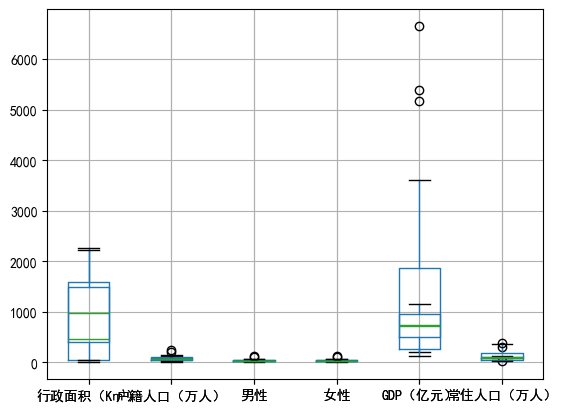

In [152]:
# 对北京地区信息进行异常值检测
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
file_data_bjinfo.boxplot(column=['行政面积（K㎡）','户籍人口（万人）','男性','女性','GDP（亿元）','常住人口（万人）'])
plt.show()

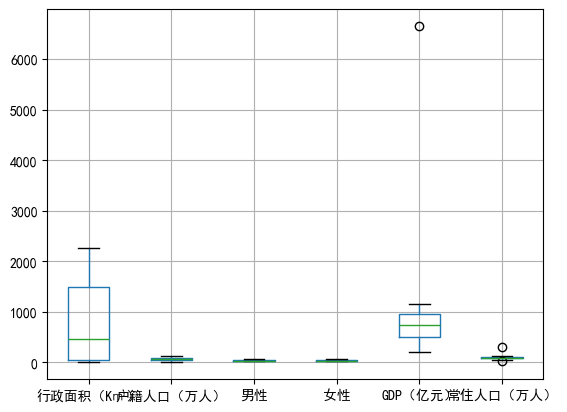

In [153]:
# 对天津地区信息进行异常值检测
file_data_tjinfo.boxplot(column=['行政面积（K㎡）','户籍人口（万人）','男性','女性','GDP（亿元）','常住人口（万人）'])
plt.show()

In [154]:
# 对两地信息数据进行合并
pd.concat([file_data_bjinfo,file_data_tjinfo],ignore_index=True)

,省级单位,地级单位,县级单位,区划类型,行政面积（K㎡）,户籍人口（万人）,男性,女性,GDP（亿元）,常住人口（万人）
0,北京,北京,西城区,市辖区,51,146.47,72.88,73.59,3602.36,125.90
1,北京,北京,东城区,市辖区,42,97.41,47.91,49.50,2061.80,87.80
2,北京,北京,丰台区,市辖区,306,115.33,58.39,56.95,1297.03,225.50
3,北京,北京,朝阳区,市辖区,455,210.91,105.43,105.48,5171.03,385.60
4,北京,北京,房山区,市辖区,1990,81.28,40.76,40.52,606.61,109.60
5,北京,北京,石景山区,市辖区,84,38.69,19.87,18.82,482.14,63.40
6,北京,北京,海淀区,市辖区,431,240.20,120.08,120.12,5395.16,359.30
7,北京,北京,通州区,市辖区,906,74.68,37.08,37.60,674.81,142.80
8,北京,北京,顺义区,市辖区,1020,62.74,31.12,31.61,1591.60,107.50
9,北京,北京,昌平区,市辖区,1344,61.14,30.72,30.41,753.39,201.00


# 5.1 数据分组

## 5.1.1 通过Series对象进行分组

In [155]:
df = pd.DataFrame({'key1': ['a', 'a', 'b', 'b', 'a'],
                  'key2': ['one', 'two', 'one', 'two', 'one'],
                  'data1': range(5),
                  'data2': range(10, 15)})
df

,key1,key2,data1,data2
0,a,one,0,10
1,a,two,1,11
2,b,one,2,12
3,b,two,3,13
4,a,one,4,14


In [156]:
grouped1 = df['data1'].groupby(df['key1'])
grouped2 = df.groupby(df['key1'])
print(type(grouped1))
print(type(grouped2))
grouped2

<class 'pandas.api.typing.SeriesGroupBy'>
<class 'pandas.api.typing.DataFrameGroupBy'>


In [157]:
grouped1.mean()

key1
a    1.666667
b    2.500000
Name: data1, dtype: float64

In [158]:
# list(grouped1)
list(grouped2)

[('a',
    key1 key2  data1  data2
  0    a  one      0     10
  1    a  two      1     11
  4    a  one      4     14),
 ('b',
    key1 key2  data1  data2
  2    b  one      2     12
  3    b  two      3     13)]

In [159]:
means = df['data1'].groupby([df['key1'], df['key2']]).mean()  # 多个分组键
means
# means.unstack()

key1  key2
a     one     2.0
      two     1.0
b     one     2.0
      two     3.0
Name: data1, dtype: float64

In [160]:
# 使用Series进行分组，2026.4更新！不再自动去除非数值列，需使用numeric_only
df.groupby(pd.Series(['a', 'a', 'b', 'b', 'a'])).mean(numeric_only=True)

,data1,data2
a,1.666667,11.666667
b,2.500000,12.500000


In [161]:
list(df.groupby(pd.Series(['one', 'one', 'two'])))  # 任意Series

[('one',
    key1 key2  data1  data2
  0    a  one      0     10
  1    a  two      1     11),
 ('two',
    key1 key2  data1  data2
  2    b  one      2     12)]

In [162]:
list(df.groupby([pd.Series(['A', 'A', 'B', 'B']), pd.Series([1, 2, 1, 2])]))

[(('A', 1.0),
    key1 key2  data1  data2
  0    a  one      0     10),
 (('A', 2.0),
    key1 key2  data1  data2
  1    a  two      1     11),
 (('B', 1.0),
    key1 key2  data1  data2
  2    b  one      2     12),
 (('B', 2.0),
    key1 key2  data1  data2
  3    b  two      3     13)]

## 5.1.2 通过列名进行分组

In [163]:
list(df.groupby('key1'))

[('a',
    key1 key2  data1  data2
  0    a  one      0     10
  1    a  two      1     11
  4    a  one      4     14),
 ('b',
    key1 key2  data1  data2
  2    b  one      2     12
  3    b  two      3     13)]

In [164]:
list(df.groupby(['key1', 'key2']))

[(('a', 'one'),
    key1 key2  data1  data2
  0    a  one      0     10
  4    a  one      4     14),
 (('a', 'two'),
    key1 key2  data1  data2
  1    a  two      1     11),
 (('b', 'one'),
    key1 key2  data1  data2
  2    b  one      2     12),
 (('b', 'two'),
    key1 key2  data1  data2
  3    b  two      3     13)]

In [165]:
print(df.groupby(['key1', 'key2']).size())  # 每个组的大小
df.groupby(['key1', 'key2']).count()

key1  key2
a     one     2
      two     1
b     one     1
      two     1
dtype: int64


data1  data2
key1 key2              
a    one       2      2
     two       1      1
b    one       1      1
     two       1      1

## 5.1.3 分组对象

In [166]:
# 遍历GroupBy对象
for name, group in df.groupby('key1'):
    print(name)
    print(group, '\n')

a
  key1 key2  data1  data2
0    a  one      0     10
1    a  two      1     11
4    a  one      4     14 

b
  key1 key2  data1  data2
2    b  one      2     12
3    b  two      3     13 



In [167]:
for (k1, k2), group in df.groupby(['key1', 'key2']):
    print(k1, k2)
    print(group, '\n')

a one
  key1 key2  data1  data2
0    a  one      0     10
4    a  one      4     14 

a two
  key1 key2  data1  data2
1    a  two      1     11 

b one
  key1 key2  data1  data2
2    b  one      2     12 

b two
  key1 key2  data1  data2
3    b  two      3     13 



In [168]:
# 仅聚合一列
print(df.groupby('key1')['data2'].mean())
df['data2'].groupby(df['key1']).mean()

key1
a    11.666667
b    12.500000
Name: data2, dtype: float64


key1
a    11.666667
b    12.500000
Name: data2, dtype: float64

In [169]:
print(df[['data2']].groupby([df['key1'], df['key2']]).mean())
df.groupby(['key1', 'key2'])[['data2']].mean()

           data2
key1 key2       
a    one    12.0
     two    11.0
b    one    12.0
     two    13.0


data2
key1 key2       
a    one    12.0
     two    11.0
b    one    12.0
     two    13.0

## 5.1.4 其他分组方式

In [170]:
# 对列进行分组，2026.4更新！groupby移除axis，不再支持按列分组，仅按行分组
#for name, group in df.groupby(['first', 'first', 'second', 'second'], axis=1):
#    print(name)
#    print(group, '\n')

In [171]:
# 通过字典进行分组
num_df = pd.DataFrame([[1, 2, 3, 4, 5], 
                       [6, 7, 8, 9, 10],
                       [11, 12, 13, 14, 15],
                       [5, 4, 3, 2, 1],
                       [10, 9, 8, 7, 6]], index=list('abcde'))
print(num_df, '\n')
for i in num_df.groupby({'a': 'first', 'b': 'first', 'c': 'second',
                     'd': 'second', 'e': 'second'}):
    print(i, '\n')

    0   1   2   3   4
a   1   2   3   4   5
b   6   7   8   9  10
c  11  12  13  14  15
d   5   4   3   2   1
e  10   9   8   7   6 

('first',    0  1  2  3   4
a  1  2  3  4   5
b  6  7  8  9  10) 

('second',     0   1   2   3   4
c  11  12  13  14  15
d   5   4   3   2   1
e  10   9   8   7   6) 



In [172]:
# 通过函数进行分组
df = pd.DataFrame({'a': [1, 2, 3, 4, 5],
                   'b': [6, 7, 8, 9, 10],
                   'c': [5, 4, 3, 2, 1]},
                  index=['Sun', 'Jack', 'Alice', 'Helen', 'Job'])
print(df, '\n')
for group in df.groupby(len):
    print(group, '\n')

       a   b  c
Sun    1   6  5
Jack   2   7  4
Alice  3   8  3
Helen  4   9  2
Job    5  10  1 

(3,      a   b  c
Sun  1   6  5
Job  5  10  1) 

(4,       a  b  c
Jack  2  7  4) 

(5,        a  b  c
Alice  3  8  3
Helen  4  9  2) 



# 5.2 数据聚合

## 5.2.1 使用内置统计方法聚合

In [173]:
df = pd.DataFrame({'key1': ['A', 'A', 'B', 'B', 'A'],
                   'key2': ['one', 'two', 'one', 'two', 'one'],
                   "data1": [2, 3, 4, 6, 8],
                   "data2": [3, 5, np.nan, 3,7]})
df

,key1,key2,data1,data2
0,A,one,2,3.0
1,A,two,3,5.0
2,B,one,4,NaN
3,B,two,6,3.0
4,A,one,8,7.0


In [174]:
# 2026.4更新！
df.groupby('key1').mean(numeric_only=True)

,data1,data2
key1,,
A,4.333333,5.0
B,5.000000,3.0


In [175]:
df.groupby('key1').describe()

data1                                              data2                 \
     count      mean       std  min  25%  50%  75%  max count mean  std  min   
key1                                                                           
A      3.0  4.333333  3.214550  2.0  2.5  3.0  5.5  8.0   3.0  5.0  2.0  3.0   
B      2.0  5.000000  1.414214  4.0  4.5  5.0  5.5  6.0   1.0  3.0  NaN  3.0   

                          
      25%  50%  75%  max  
key1                      
A     4.0  5.0  6.0  7.0  
B     3.0  3.0  3.0  3.0

## 5.2.2 面向列的聚合

In [176]:
data_frame = pd.DataFrame(np.arange(36).reshape((6, 6)),
                       columns=list('ABCDEF'))
data_frame['key'] = pd.Series(list('aaabbb'), name='key')
data_frame

,A,B,C,D,E,F,key
0,0,1,2,3,4,5,a
1,6,7,8,9,10,11,a
2,12,13,14,15,16,17,a
3,18,19,20,21,22,23,b
4,24,25,26,27,28,29,b
5,30,31,32,33,34,35,b


In [177]:
data_group = data_frame.groupby('key')
dict([x for x in data_group])['a']

,A,B,C,D,E,F,key
0,0,1,2,3,4,5,a
1,6,7,8,9,10,11,a
2,12,13,14,15,16,17,a


In [178]:
dict([x for x in data_group])['b']

,A,B,C,D,E,F,key
3,18,19,20,21,22,23,b
4,24,25,26,27,28,29,b
5,30,31,32,33,34,35,b


In [179]:
data_group.agg(sum)

,A,B,C,D,E,F
key,,,,,,
a,18,21,24,27,30,33
b,72,75,78,81,84,87


In [180]:
def range_data_group(arr):
    return arr.max()-arr.min()
data_group.agg(range_data_group) 

,A,B,C,D,E,F
key,,,,,,
a,12,12,12,12,12,12
b,12,12,12,12,12,12


## 5.2.3 使用多函数聚合

In [181]:
# data_group.agg([range_data_group, sum])
data_group.agg([range_data_group, 'sum'])

A                    B                    C      \
    range_data_group sum range_data_group sum range_data_group sum   
key                                                                  
a                 12  18               12  21               12  24   
b                 12  72               12  75               12  78   

                   D                    E                    F      
    range_data_group sum range_data_group sum range_data_group sum  
key                                                                 
a                 12  27               12  30               12  33  
b                 12  81               12  84               12  87

In [182]:
data_group.agg([("极差", range_data_group), ("和", 'sum')])

A       B       C       D       E       F    
     极差   和  极差   和  极差   和  极差   和  极差   和  极差   和
key                                                
a    12  18  12  21  12  24  12  27  12  30  12  33
b    12  72  12  75  12  78  12  81  12  84  12  87

In [183]:
data_group.agg({'A': 'sum', 'B': 'mean', 'C': range_data_group})

,A,B,C
key,,,
a,18,7.0,12
b,72,25.0,12


# 5.3 其他分组级运算

## 5.3.1 数据转换

In [184]:
df = pd.DataFrame({'a': [0, 1, 6, 10, 3],
                   'b': [1, 2, 7, 11, 4],
                   'c': [2, 3, 8, 12, 4],
                   'd': [3, 4, 9, 13, 5],
                   'e': [4, 5, 10, 14, 3],
                   'key': ['A', 'A', 'B', 'B', 'B']})
df

,a,b,c,d,e,key
0,0,1,2,3,4,A
1,1,2,3,4,5,A
2,6,7,8,9,10,B
3,10,11,12,13,14,B
4,3,4,4,5,3,B


In [185]:
df.groupby('key').transform('mean')

,a,b,c,d,e
0,0.500000,1.500000,2.5,3.5,4.5
1,0.500000,1.500000,2.5,3.5,4.5
2,6.333333,7.333333,8.0,9.0,9.0
3,6.333333,7.333333,8.0,9.0,9.0
4,6.333333,7.333333,8.0,9.0,9.0


In [186]:
df = pd.DataFrame({'A': [2, 3, 3, 4, 2],
                   'B': [4, 2, 3, 6, 6],
                   'C': [9, 7, 0, 7, 8],
                   'D': [3, 4, 8, 6, 10]})
df

,A,B,C,D
0,2,4,9,3
1,3,2,7,4
2,3,3,0,8
3,4,6,7,6
4,2,6,8,10


In [187]:
key = ['one','one','two',' two',' two']
df.groupby(key).transform('mean')

,A,B,C,D
0,2.5,3.0,8.0,3.5
1,2.5,3.0,8.0,3.5
2,3.0,3.0,0.0,8.0
3,3.0,6.0,7.5,8.0
4,3.0,6.0,7.5,8.0


In [188]:
df = pd.DataFrame(np.random.randn(5, 4))
df.groupby(key).transform(lambda x: x - x.mean())

,0,1,2,3
0,-1.441691,-0.701494,0.359705,-0.694631
1,1.441691,0.701494,-0.359705,0.694631
2,0.000000,0.000000,0.000000,0.000000
3,-1.910849,0.171118,0.202339,-0.226790
4,1.910849,-0.171118,-0.202339,0.226790


## 5.3.2 数据应用

In [189]:
data_frame = pd.DataFrame({'data1': [80,23,25,63,94,92,99,92,82,99],
                           'data2': [41,87,58,68,72,89,60,42,53,65],
                           'data3': [30,78,23,66,16,59,20,23,24,40],
                           'key': list('baabbabaaa')})
data_frame

,data1,data2,data3,key
0,80,41,30,b
1,23,87,78,a
2,25,58,23,a
3,63,68,66,b
4,94,72,16,b
5,92,89,59,a
6,99,60,20,b
7,92,42,23,a
8,82,53,24,a
9,99,65,40,a


In [190]:
data_by_group = data_frame.groupby('key')
dict([x for x in data_by_group])['a']

,data1,data2,data3,key
1,23,87,78,a
2,25,58,23,a
5,92,89,59,a
7,92,42,23,a
8,82,53,24,a
9,99,65,40,a


In [191]:
dict([x for x in data_by_group])['b']

,data1,data2,data3,key
0,80,41,30,b
3,63,68,66,b
4,94,72,16,b
6,99,60,20,b


In [192]:
data_by_group.apply(max)  # 替代聚合

key
a    data3
b    data3
dtype: str

# 5.4 拆分 - 应用 - 合并的示例

## 5.4.1 分组加权平均

In [193]:
df = pd.DataFrame({'category': ['a', 'a', 'a', 'a',
                               'b', 'b', 'b', 'b'],
                  'data': np.random.randn(8),
                  'weights': np.random.rand(8)})
df

,category,data,weights
0,a,0.512429,0.925014
1,a,1.145257,0.285509
2,a,0.084596,0.418276
3,a,1.014880,0.729832
4,b,-1.171019,0.738538
5,b,0.783443,0.368391
6,b,-0.998110,0.702498
7,b,-0.999064,0.270618


In [194]:
df.groupby('category').apply(lambda g: np.average(g['data'], weights=g['weights']))

category
a    0.668634
b   -0.744101
dtype: float64

## 5.4.2 分组填充缺失值

In [195]:
data = pd.Series(np.random.randn(8),
                index=['Beijing', 'Tianjin', 'Jinan', 'Dalian',
                      'Shanghai', 'Guangzhou', 'Shenzhen', 'Wuhan'])
data[['Jinan', 'Guangzhou', 'Wuhan']] = np.nan
data

Beijing      0.793245
Tianjin      1.466667
Jinan             NaN
Dalian      -0.439456
Shanghai     0.028786
Guangzhou         NaN
Shenzhen    -0.216477
Wuhan             NaN
dtype: float64

In [196]:
# 使用整体平均值填充
data.fillna(data.mean())

Beijing      0.793245
Tianjin      1.466667
Jinan        0.326553
Dalian      -0.439456
Shanghai     0.028786
Guangzhou    0.326553
Shenzhen    -0.216477
Wuhan        0.326553
dtype: float64

In [197]:
group_key = ['North'] * 4 + ['South'] * 4
data.groupby(group_key).mean()

North    0.606819
South   -0.093846
dtype: float64

In [198]:
# 使用分组的平均值填充
data.groupby(group_key).apply(lambda g: g.fillna(g.mean()))

North  Beijing      0.793245
       Tianjin      1.466667
       Jinan        0.606819
       Dalian      -0.439456
South  Shanghai     0.028786
       Guangzhou   -0.093846
       Shenzhen    -0.216477
       Wuhan       -0.093846
dtype: float64

In [199]:
# 分组内使用指定的值填充
fill_values = {'North': 0.5, 'South': -1}
data.groupby(group_key).apply(lambda g: g.fillna(fill_values[g.name]))

North  Beijing      0.793245
       Tianjin      1.466667
       Jinan        0.500000
       Dalian      -0.439456
South  Shanghai     0.028786
       Guangzhou   -1.000000
       Shenzhen    -0.216477
       Wuhan       -1.000000
dtype: float64

## 5.4.3 分组随机抽样

In [200]:
suits = ['Heart', 'Spade', 'Club', 'Diamond']
card_val = (list(range(1, 11)) + [10] * 3) * 4
base_names = ['A'] + list(range(2, 11)) + ['J', 'Q', 'K']
cards = []
for suit in suits:
    cards.extend(suit + ' ' + str(num) for num in base_names)
deck = pd.Series(card_val, index=cards)
deck

Heart A        1
Heart 2        2
Heart 3        3
Heart 4        4
Heart 5        5
Heart 6        6
Heart 7        7
Heart 8        8
Heart 9        9
Heart 10      10
Heart J       10
Heart Q       10
Heart K       10
Spade A        1
Spade 2        2
Spade 3        3
Spade 4        4
Spade 5        5
Spade 6        6
Spade 7        7
Spade 8        8
Spade 9        9
Spade 10      10
Spade J       10
Spade Q       10
Spade K       10
Club A         1
Club 2         2
Club 3         3
Club 4         4
Club 5         5
Club 6         6
Club 7         7
Club 8         8
Club 9         9
Club 10       10
Club J        10
Club Q        10
Club K        10
Diamond A      1
Diamond 2      2
Diamond 3      3
Diamond 4      4
Diamond 5      5
Diamond 6      6
Diamond 7      7
Diamond 8      8
Diamond 9      9
Diamond 10    10
Diamond J     10
Diamond Q     10
Diamond K     10
dtype: int64

In [201]:
# 随机抽取n张牌
def draw(deck, n=5):
    return deck.sample(n)
draw(deck)

Spade Q      10
Club 4        4
Heart J      10
Diamond 8     8
Club 7        7
dtype: int64

In [202]:
# 每种花色随机抽取n张牌
deck.groupby(lambda card: card.split(' ')[0], group_keys=False).apply(draw, n=2)

Club 6        6
Club 2        2
Diamond 9     9
Diamond 2     2
Heart 6       6
Heart 4       4
Spade Q      10
Spade 4       4
dtype: int64

# 5.5	案例—运动员信息的分组与聚合

In [203]:
df = pd.read_csv('athletes.csv')
df

,姓名,性别,出生年份（年）,年龄（岁）,身高(cm),体重(kg),项目,省份
0,陈楠,女,1983年,35,197,90,篮球,山东省
1,白发全,男,1986年,32,175,64,铁人三项,云南省
2,陈晓佳,女,1988年,30,180,70,篮球,江苏省
3,陈倩,女,1987年,31,163,54,女子现代五项,江苏省
4,曹忠荣,男,1981年,37,180,73,男子现代五项,上海市
...,...,...,...,...,...,...,...,...
174,赵芸蕾,女,1986年,32,173,62,羽毛球,湖北省
175,周琦,男,1996年,22,217,95,篮球,河南省
176,翟晓川,男,1993年,25,204,100,篮球,河北省
177,赵继伟,男,1995年,23,185,77,篮球,辽宁省


In [204]:
# 按项目分组
df_basketball = dict([x for x in df.groupby('项目')])['篮球']
df_basketball

,姓名,性别,出生年份（年）,年龄（岁）,身高(cm),体重(kg),项目,省份
0,陈楠,女,1983年,35,197,90,篮球,山东省
2,陈晓佳,女,1988年,30,180,70,篮球,江苏省
16,丁彦雨航,男,1993年,25,200,91,篮球,新疆维吾尔自治区
23,高颂,女,1992年,26,191,85,篮球,黑龙江省
28,郭艾伦,男,1993年,25,192,85,篮球,辽宁省
35,黄红枇,女,1989年,29,195,80,篮球,广西壮族自治区
42,黄思静,女,1996年,22,192,80,篮球,广东省
48,李慕豪,男,1992年,26,225,111,篮球,贵州贵阳
54,李珊珊,女,1987年,31,177,70,篮球,江苏省
73,露雯,女,1990年,28,191,78,篮球,内蒙古自治区


In [205]:
# 按性别进行分组，2026.4更新！
groupby_sex = df_basketball.groupby('性别')
groupby_sex.mean(numeric_only=True)

,年龄（岁）,身高(cm),体重(kg)
性别,,,
女,28.000000,189.600000,77.900000
男,25.272727,205.090909,97.727273


In [206]:
# 使用transform方法广播，2026.4更新！transform不支持自动过滤非数值列
#groupby_sex.transform('mean')
groupby_sex[df_basketball.select_dtypes('number').columns].transform('mean')

,年龄（岁）,身高(cm),体重(kg)
0,28.000000,189.600000,77.900000
2,28.000000,189.600000,77.900000
16,25.272727,205.090909,97.727273
23,28.000000,189.600000,77.900000
28,25.272727,205.090909,97.727273
35,28.000000,189.600000,77.900000
42,28.000000,189.600000,77.900000
48,25.272727,205.090909,97.727273
54,28.000000,189.600000,77.900000
73,28.000000,189.600000,77.900000


In [207]:
# 查看男篮运动员的分组
baseketball_male = dict([x for x in groupby_sex])['男']
baseketball_male

,姓名,性别,出生年份（年）,年龄（岁）,身高(cm),体重(kg),项目,省份
16,丁彦雨航,男,1993年,25,200,91,篮球,新疆维吾尔自治区
28,郭艾伦,男,1993年,25,192,85,篮球,辽宁省
48,李慕豪,男,1992年,26,225,111,篮球,贵州贵阳
106,睢冉,男,1992年,26,192,95,篮球,山西省
124,王哲林,男,1994年,24,214,110,篮球,福建省
155,易建联,男,1987年,31,213,113,篮球,广东省
161,周鹏,男,1989年,29,206,90,篮球,辽宁省
175,周琦,男,1996年,22,217,95,篮球,河南省
176,翟晓川,男,1993年,25,204,100,篮球,河北省
177,赵继伟,男,1995年,23,185,77,篮球,辽宁省


In [208]:
# 求年龄、身高、体重这三列数据的极差值
def range_data_group(arr):
    return arr.max()-arr.min()
baseketball_male.agg({'年龄（岁）':range_data_group,
                      '身高(cm)':range_data_group,
                      '体重(kg)':range_data_group})

年龄（岁）      9
身高(cm)    40
体重(kg)    36
dtype: int64

In [209]:
# 添加“体质指数”列
df_basketball['体质指数'] = 0
df_basketball

,姓名,性别,出生年份（年）,年龄（岁）,身高(cm),体重(kg),项目,省份,体质指数
0,陈楠,女,1983年,35,197,90,篮球,山东省,0
2,陈晓佳,女,1988年,30,180,70,篮球,江苏省,0
16,丁彦雨航,男,1993年,25,200,91,篮球,新疆维吾尔自治区,0
23,高颂,女,1992年,26,191,85,篮球,黑龙江省,0
28,郭艾伦,男,1993年,25,192,85,篮球,辽宁省,0
35,黄红枇,女,1989年,29,195,80,篮球,广西壮族自治区,0
42,黄思静,女,1996年,22,192,80,篮球,广东省,0
48,李慕豪,男,1992年,26,225,111,篮球,贵州贵阳,0
54,李珊珊,女,1987年,31,177,70,篮球,江苏省,0
73,露雯,女,1990年,28,191,78,篮球,内蒙古自治区,0


In [210]:
# 计算BMI值
def outer(num):
    def ath_bmi(sum_bmi):
        weight = df_basketball['体重(kg)']
        height = df_basketball['身高(cm)'] 
        sum_bmi =  weight / (height/100)**2
        return num + sum_bmi
    return ath_bmi
all_bmi = df_basketball['体质指数']
df_basketball['体质指数'] = df_basketball[['体质指数']].apply(outer(all_bmi))
df_basketball

,姓名,性别,出生年份（年）,年龄（岁）,身高(cm),体重(kg),项目,省份,体质指数
0,陈楠,女,1983年,35,197,90,篮球,山东省,23.190497
2,陈晓佳,女,1988年,30,180,70,篮球,江苏省,21.604938
16,丁彦雨航,男,1993年,25,200,91,篮球,新疆维吾尔自治区,22.750000
23,高颂,女,1992年,26,191,85,篮球,黑龙江省,23.299800
28,郭艾伦,男,1993年,25,192,85,篮球,辽宁省,23.057726
35,黄红枇,女,1989年,29,195,80,篮球,广西壮族自治区,21.038790
42,黄思静,女,1996年,22,192,80,篮球,广东省,21.701389
48,李慕豪,男,1992年,26,225,111,篮球,贵州贵阳,21.925926
54,李珊珊,女,1987年,31,177,70,篮球,江苏省,22.343516
73,露雯,女,1990年,28,191,78,篮球,内蒙古自治区,21.380993


# 6.2 Seaborn

## 6.2.1 Pandas内置绘图

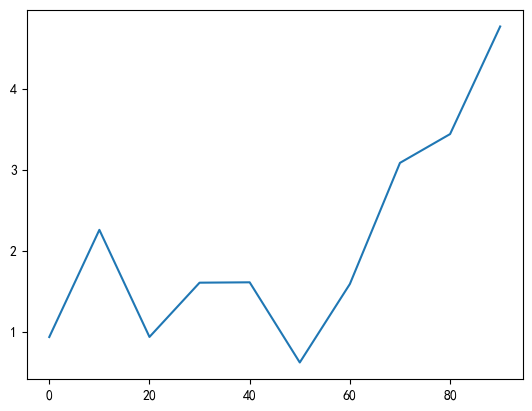

In [211]:
# Series绘图
np.random.seed(20201111)
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()
plt.show()

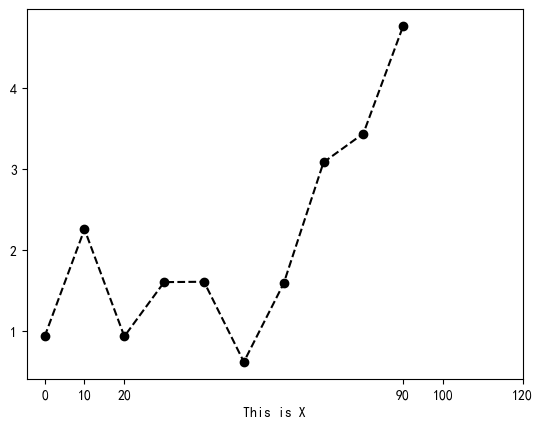

In [212]:
np.random.seed(20201111)
fig, ax = plt.subplots()
s = pd.Series(np.random.randn(10).cumsum(), index=np.arange(0, 100, 10))
#s.plot(ax=ax, style='ko--', xticks=[0, 10, 20, 90, 100, 120], xlabel='This is X')
s.plot.line(ax=ax, style='ko--', xticks=[0, 10, 20, 90, 100, 120], xlabel='This is X')
plt.show()

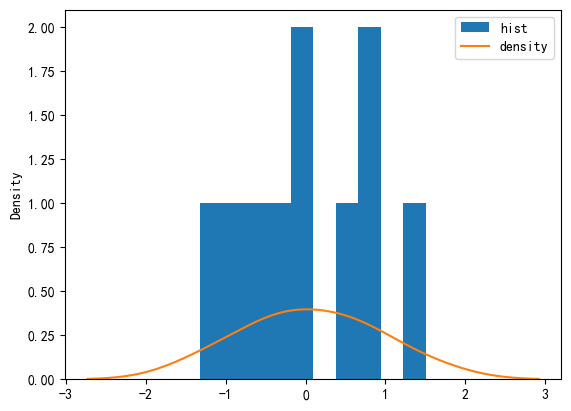

In [213]:
# Series绘图：直方图
fig, ax = plt.subplots()
s = pd.Series(np.random.randn(10))
#s.plot(ax=ax, kind='bar')
s.plot.hist(ax=ax, label='hist')
s.plot.density(ax=ax, label='density')
plt.legend()
plt.show()

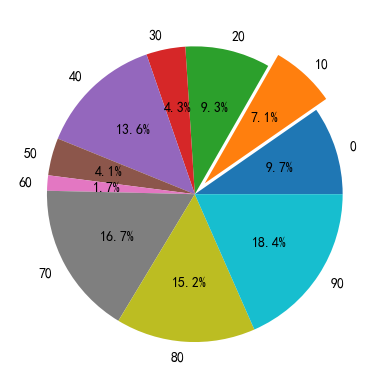

In [214]:
# Series绘图：饼图
fig, ax = plt.subplots()
s = pd.Series(np.random.randint(1, 100, size=10), index=np.arange(0, 100, 10))

explode = np.zeros(10)
explode[1] = .1
s.plot.pie(ax=ax, explode=explode, autopct='%1.1f%%')
plt.show()

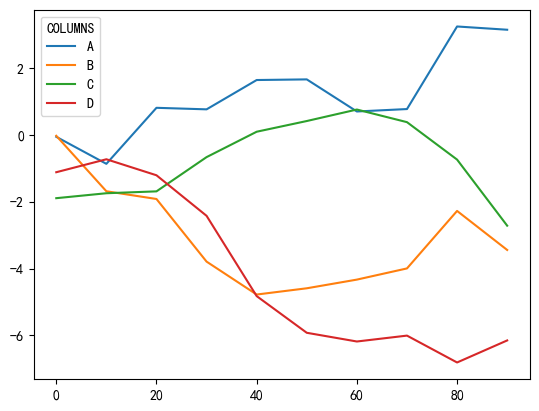

In [215]:
# DataFrame绘图
np.random.seed(20201116)
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                 columns=pd.Index(['A', 'B', 'C', 'D'], name='COLUMNS'),
                 index=np.arange(0, 100, 10))
df.plot()
plt.show()

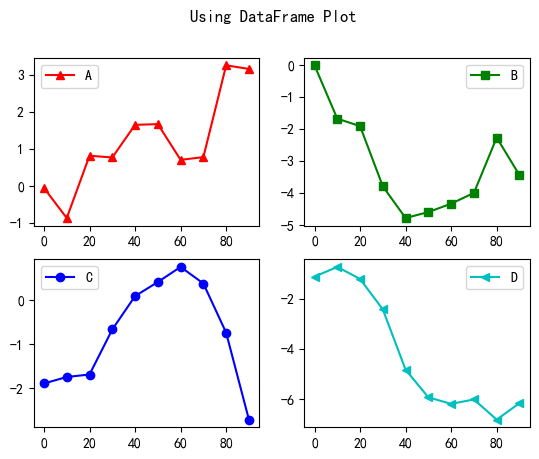

In [216]:
# 各列使用独立的子图
np.random.seed(20201116)
fig, axes = plt.subplots(2, 2)
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0),
                 columns=['A', 'B', 'C', 'D'],
                 index=np.arange(0, 100, 10))
df.plot(ax=axes, subplots=True, title='Using DataFrame Plot', style=['r^-', 'gs-', 'bo-', 'c<-'])
plt.show()

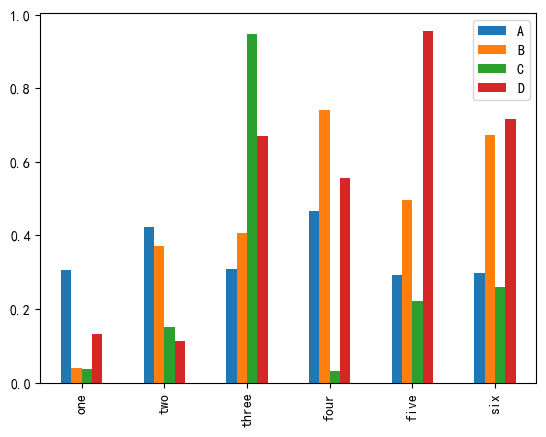

In [217]:
# DataFrame绘图：条形图
np.random.seed(20201116)
fig, ax = plt.subplots()
df = pd.DataFrame(np.random.rand(6, 4),
                  columns=['A', 'B', 'C', 'D'],
                  index=['one', 'two', 'three', 'four', 'five', 'six'])
df.plot.bar(ax=ax)
plt.show()

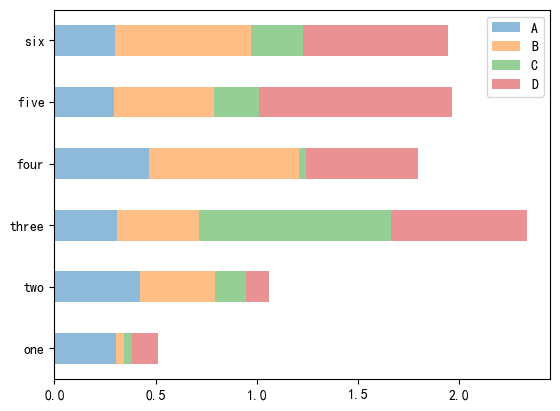

In [218]:
# DataFrame绘图：水平堆积条形图
np.random.seed(20201116)
fig, ax = plt.subplots()
df = pd.DataFrame(np.random.rand(6, 4),
                  columns=['A', 'B', 'C', 'D'],
                  index=['one', 'two', 'three', 'four', 'five', 'six'])
df.plot.barh(ax=ax, stacked=True, alpha=0.5)
plt.show()

## 6.2.2 Seaborn使用示例

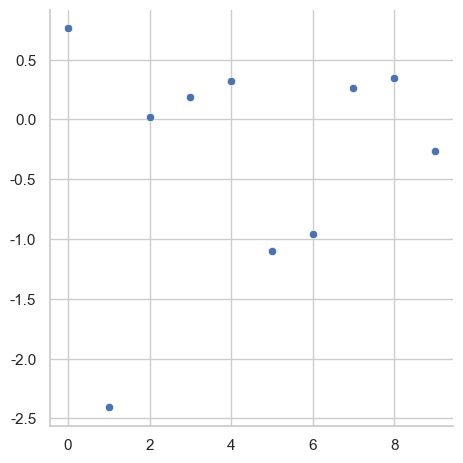

In [219]:
# Seaborn主题风格
sns.set_theme(context='notebook', style='whitegrid')
sns.relplot(data=np.random.randn(10))
plt.show()

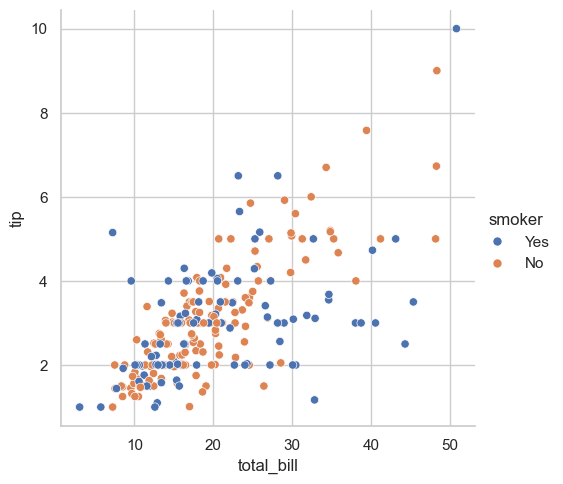

In [220]:
tips = sns.load_dataset('tips', data_home='.')
sns.relplot(data=tips, x='total_bill', y='tip', hue='smoker')
plt.show()

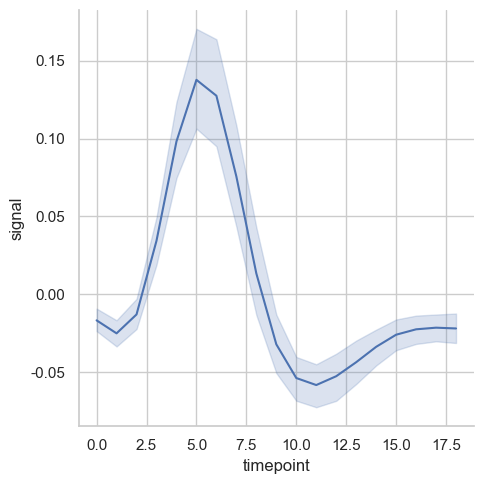

In [221]:
# Seaborn示例
fmri = sns.load_dataset('fmri', data_home='.')
sns.relplot(x='timepoint', y='signal', kind='line', data=fmri)
plt.show()

## 6.2.3 可视化数据的分布

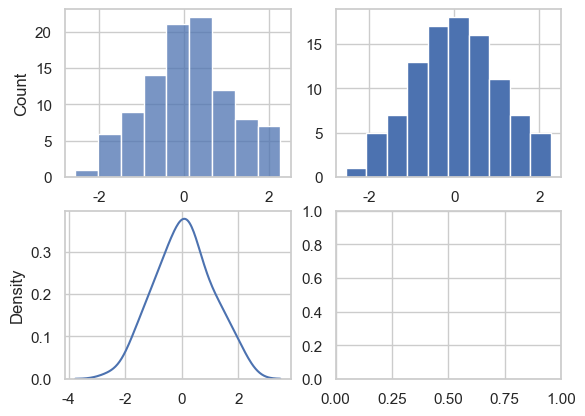

In [222]:
# 直方图与密度图
np.random.seed(0)
arr = np.random.randn(100)

fig, axes = plt.subplots(2, 2)
sns.histplot(arr, ax=axes[0, 0])
axes[0, 1].hist(arr)
sns.kdeplot(arr, ax=axes[1, 0])
plt.show()

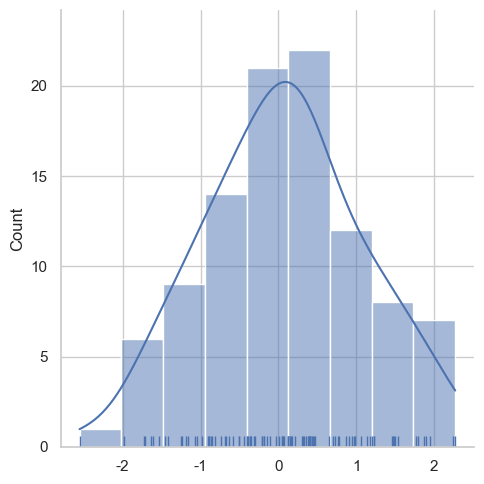

In [223]:
sns.displot(arr, kde=True, rug=True)
plt.show()

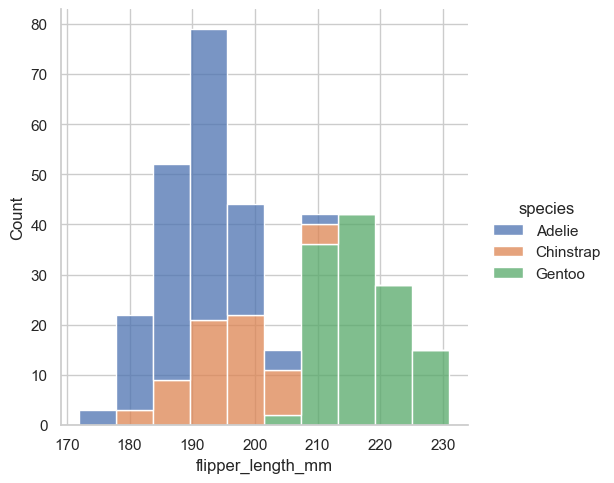

In [224]:
penguins = sns.load_dataset("penguins", data_home='.')
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")
plt.show()

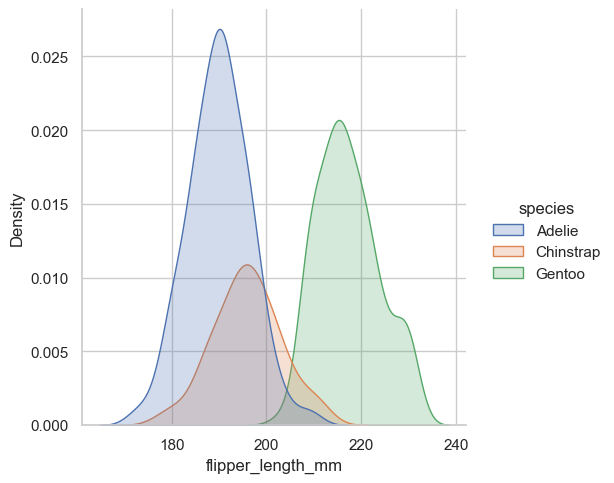

In [225]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", kind="kde", fill=True)
plt.show()

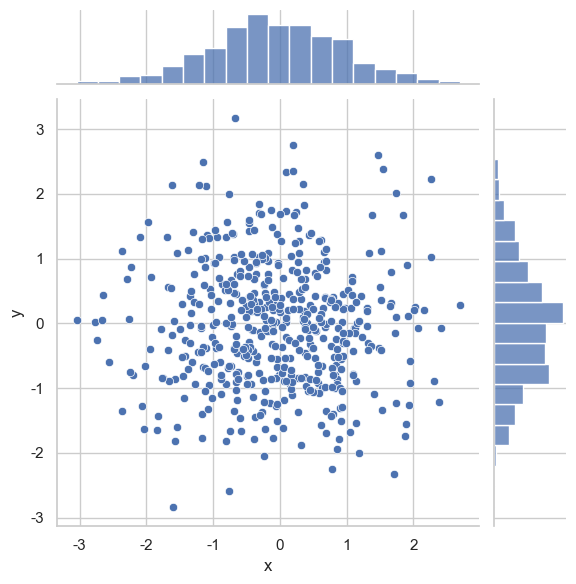

In [226]:
# 散点图
dataframe_obj = pd.DataFrame({"x": np.random.randn(500),"y": np.random.randn(500)})
sns.jointplot(x="x", y="y", data=dataframe_obj)
plt.show()

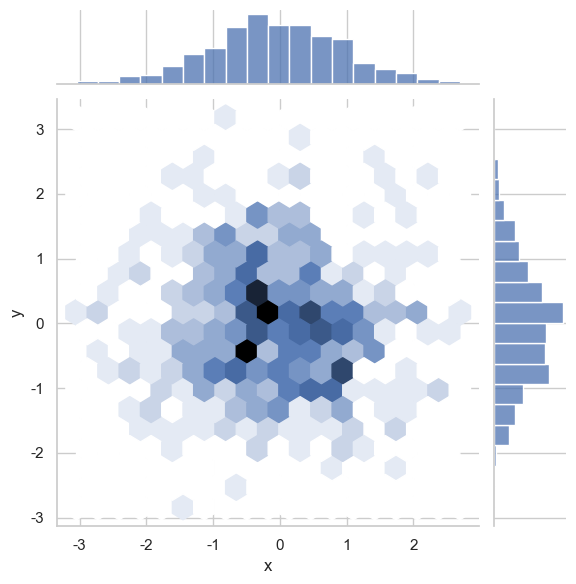

In [227]:
# 二维直方图
sns.jointplot(x="x", y="y", data=dataframe_obj, kind="hex")
plt.show()

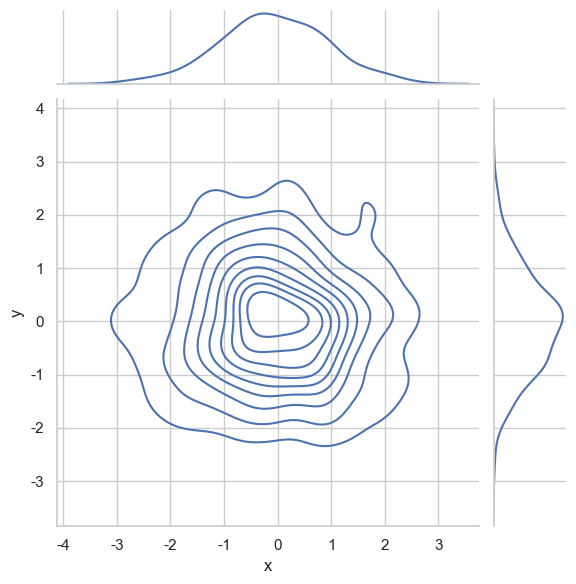

In [228]:
# 核密度估计
sns.jointplot(x="x", y="y", data=dataframe_obj, kind="kde")
plt.show()

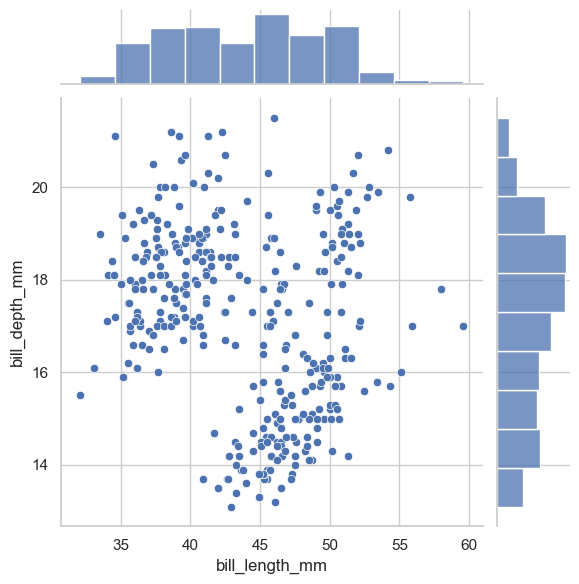

In [229]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")
plt.show()

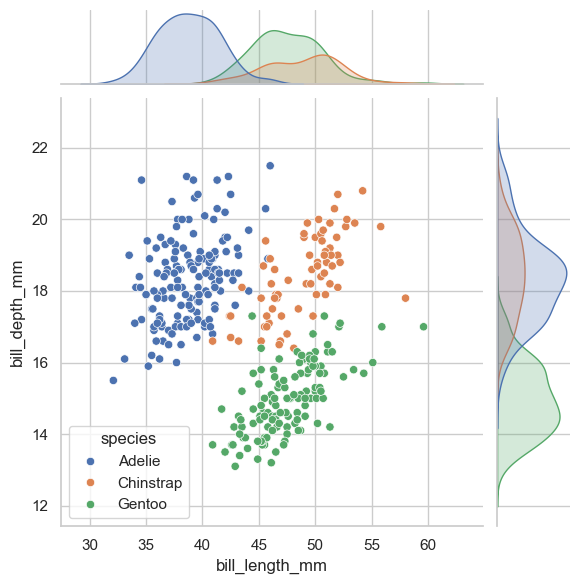

In [230]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.show()

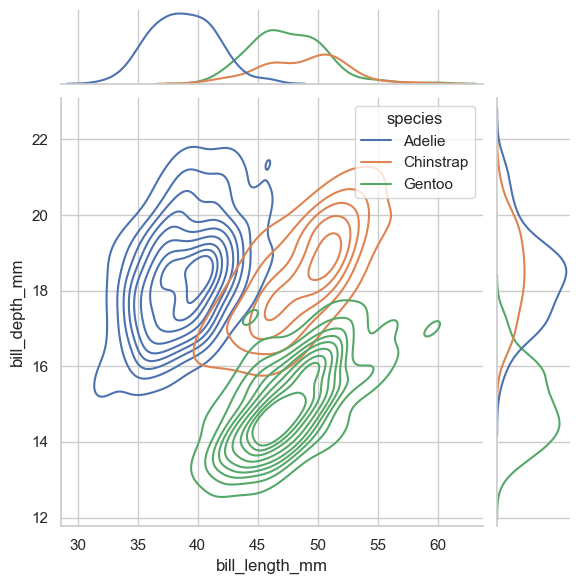

In [231]:
sns.jointplot(data=penguins, x="bill_length_mm", y="bill_depth_mm", hue="species", kind="kde")
plt.show()

## 6.2.4 用分类数据绘图

In [232]:
# 鸢尾花数据集
iris = sns.load_dataset("iris", data_home='.')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


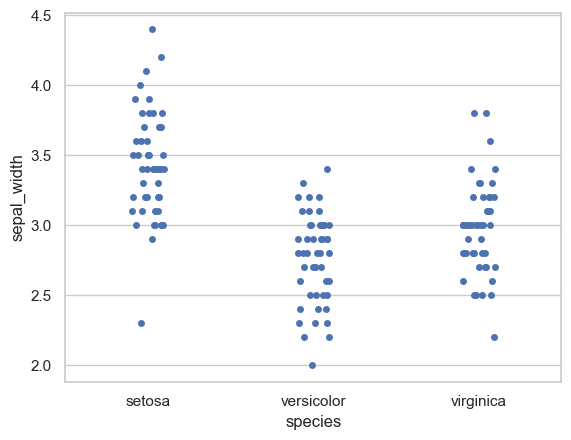

In [233]:
# 观察萼片宽度与鸢尾花种类之间的关系
sns.stripplot(x="species", y="sepal_width", data=iris)
plt.show()

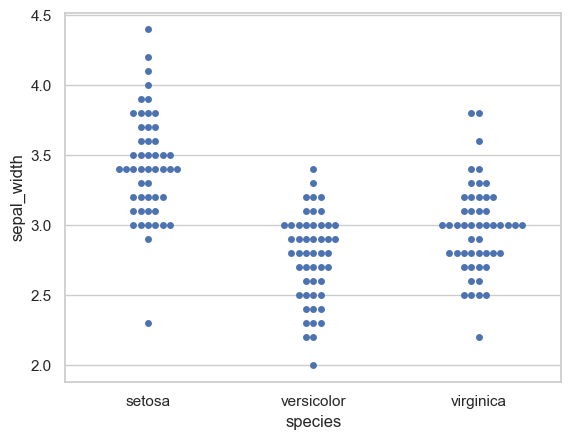

In [234]:
sns.swarmplot(x="species", y="sepal_width", data=iris)
plt.show()

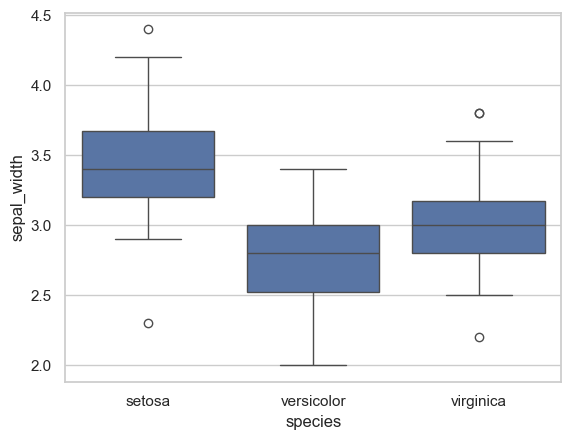

In [235]:
# 观察每种鸢尾花的萼片宽度分布
sns.boxplot(x="species", y="sepal_width", data=iris)
plt.show()

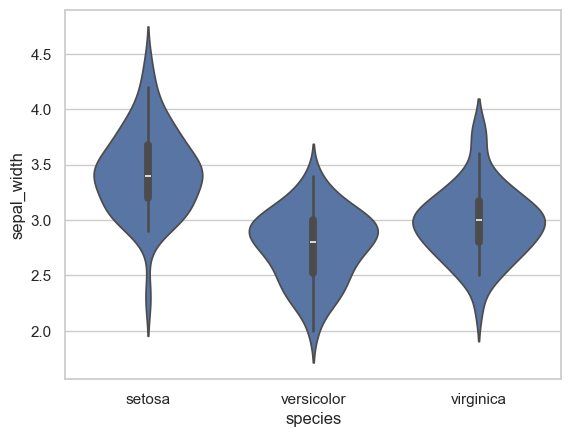

In [236]:
sns.violinplot(x="species", y="sepal_width", data=iris)
plt.show()

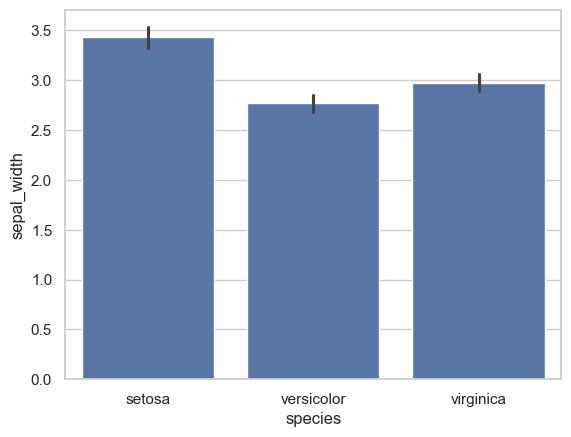

In [237]:
sns.barplot(x="species", y="sepal_width", data=iris)
plt.show()

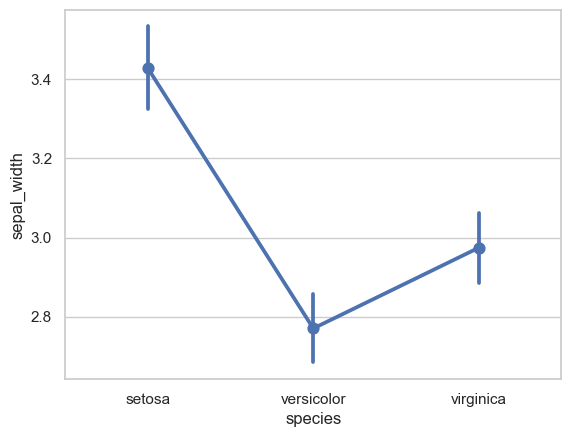

In [238]:
sns.pointplot(x="species", y="sepal_width", data=iris)
plt.show()

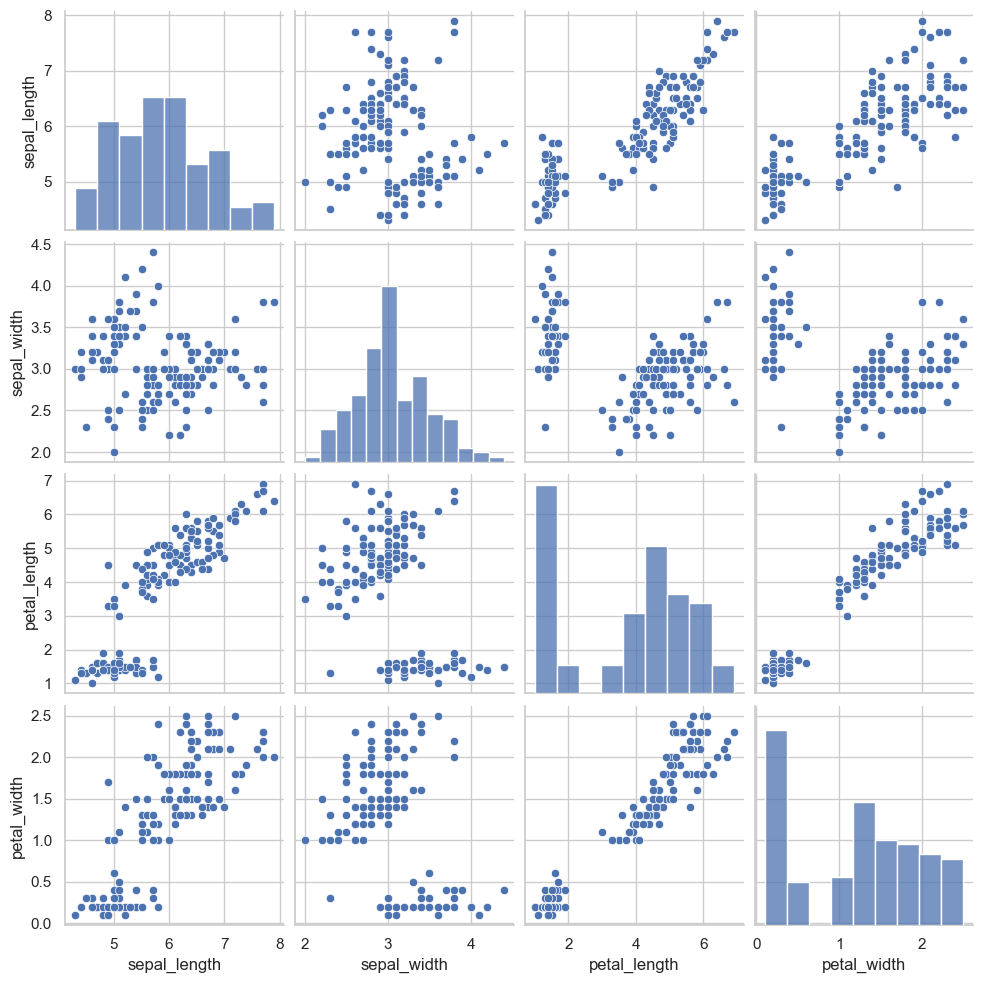

In [239]:
# 绘制成对的双变量分布
sns.pairplot(iris)
plt.show()

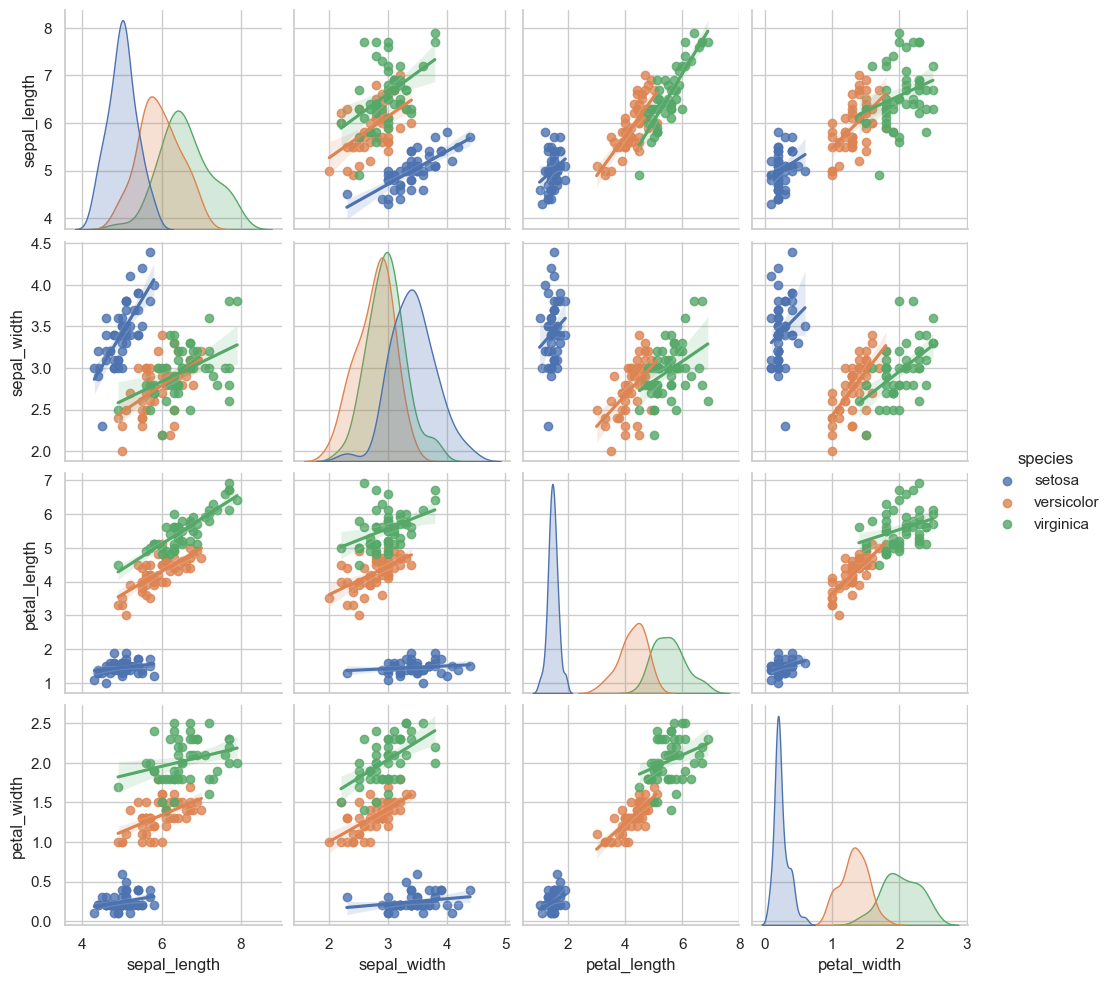

In [240]:
sns.pairplot(iris, kind='reg', hue='species')
plt.show()

In [241]:
# 鸢尾花数据的1-NN分类
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

iris_dataset = load_iris()
x_train, x_test, y_train, y_test = train_test_split(
    iris_dataset['data'],iris_dataset['target'], random_state=0)
iris_dataframe = pd.DataFrame(x_train, columns=iris_dataset.feature_names)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train, y_train)

x_new = np.array([[5, 2.9, 1, 0.2]])
knn.predict(x_new)

array([0])

# 6.3 Bokeh

In [242]:
from bokeh.plotting import figure, output_file, show
from bokeh.io import output_notebook
output_notebook()

x = [1, 2, 3, 4, 5]
y = [6, 7, 2, 4, 5]

p = figure(title="simple line example", x_axis_label='x', y_axis_label='y')
p.line(x, y, legend_label="Temp.", line_width=2)
show(p)

Loading BokehJS ...

# 6.4 案例—画图分析某年旅游景点数据

In [243]:
# 读取数据
scenery_data = pd.read_csv('mingsheng.csv')
scenery_data

,省份,名称,总面积(平方公里),游客量(万人次)
0,北京,十三陵,123.0,493.9
1,北京,八达岭,55.0,737.5
2,北京,石花洞,85.0,64.4
3,天津,盘山,106.0,228.3
4,河北,苍岩山,63.0,54.0
...,...,...,...,...
225,新疆,库木塔格沙漠,1880.0,16.5
226,新疆,天山天池,548.0,185.7
227,新疆,赛里木湖,1301.0,55.0
228,新疆,罗布人村寨,134.0,60.1


In [244]:
# 数据预处理
scenery_data.isna().sum()

省份           0
名称           0
总面积(平方公里)    1
游客量(万人次)     2
dtype: int64

In [245]:
# 使用平均值填充缺失值
area = float("{:.1f}".format(scenery_data['总面积(平方公里)'].mean()))
tourist = float("{:.1}".format(scenery_data['游客量(万人次)'].mean()))
values = {"总面积(平方公里)": area,"游客量(万人次)": tourist}
scenery_data = scenery_data.fillna(value=values)
scenery_data

,省份,名称,总面积(平方公里),游客量(万人次)
0,北京,十三陵,123.0,493.9
1,北京,八达岭,55.0,737.5
2,北京,石花洞,85.0,64.4
3,天津,盘山,106.0,228.3
4,河北,苍岩山,63.0,54.0
...,...,...,...,...
225,新疆,库木塔格沙漠,1880.0,16.5
226,新疆,天山天池,548.0,185.7
227,新疆,赛里木湖,1301.0,55.0
228,新疆,罗布人村寨,134.0,60.1


In [246]:
# 按省份分组
data = scenery_data.groupby("省份")
shaanxi_scenery = dict([x for x in data])['陕西']
shaanxi_scenery

,省份,名称,总面积(平方公里),游客量(万人次)
213,陕西,临潼骊山,120.0,1851.0
214,陕西,宝鸡天台山,134.0,3.8
215,陕西,合阳洽川,177.0,52.7
216,陕西,华山,148.0,167.0
217,陕西,黄河壶口瀑布,178.0,87.0
218,陕西,黄帝陵,3.0,66.0


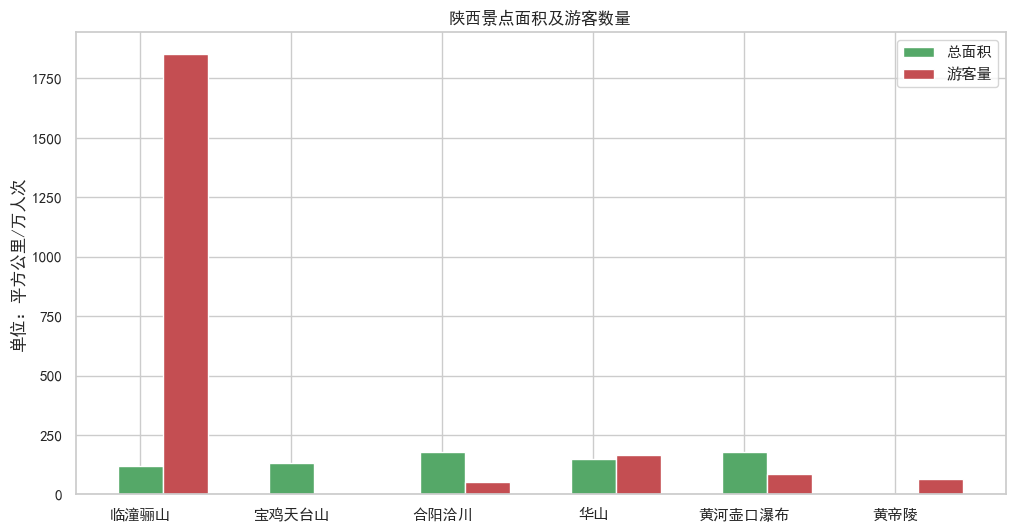

In [250]:
area = shaanxi_scenery['总面积(平方公里)'].values
tourist = shaanxi_scenery['游客量(万人次)'].values

plt.figure(figsize=(12, 6))
x_num = range(0, len(area))
x_dis = [i + 0.3 for i in x_num]
plt.bar(x_num, area, color='g', width=.3, label='总面积')
plt.bar(x_dis, tourist, color='r', width=.3, label='游客量')
plt.ylabel('单位：平方公里/万人次')
plt.title('陕西景点面积及游客数量')
plt.legend(loc='upper right')
plt.xticks(range(0, 6), shaanxi_scenery['名称'])
plt.show()

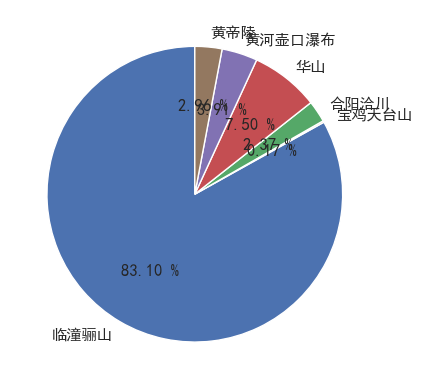

In [251]:
every_scenery = shaanxi_scenery['游客量(万人次)'].values
all_scenery = shaanxi_scenery['游客量(万人次)'].sum()

# 计算每个景点游客所占百分比
percentage = (every_scenery / all_scenery) * 100
np.set_printoptions(precision=2)
labels = shaanxi_scenery['名称']
plt.axes(aspect=1)
plt.pie(x=percentage, labels=labels, autopct='%3.2f %%',
        shadow=False, startangle=90)
plt.show()